# Интерпретация

In [13]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

### Загрузка и подготовка данных

Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [14]:
data_path = r'./data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()

Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

TARGET = 'price_target'

data = data.dropna().reset_index(drop=True)

rooms_map = {'студия': 0, '1': 1, '2': 2, '3': 3, '>=4': 4}
data['rooms_4'] = data['rooms_4'].map(rooms_map).astype(float)

data['agreement_date'] = pd.to_datetime(data['agreement_date'])
data['agreement_date'] = (data['agreement_date'] - data['agreement_date'].min()).dt.days.astype(float)

data = pd.get_dummies(data, columns=['region_name_cat'], drop_first=True)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(float)

const_cols = [c for c in data.columns if c != TARGET and data[c].nunique() == 1]
data = data.drop(columns=const_cols)

feature_cols = [c for c in data.columns if c != TARGET]
feat_names = feature_cols
cat_coded = [c for c in feature_cols if c.endswith('_cat') or c == 'rooms_4' or c.startswith('region_name_cat_')]
num_cols = [c for c in feature_cols if c not in cat_coded]

X = data[feature_cols].values.astype(float)
y = data[TARGET].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

std_scaler = StandardScaler()
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)

print(f"Размер после dropna: {data.shape}, признаков: {len(feature_cols)}")


def print_metrics(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"{name:42s} MSE={mse:14.1f}  RMSE={rmse:9.2f}  MAPE={mape:6.3f}")


models_raw = {
    'LinearRegression (без норм.)': LinearRegression(),
    'Lasso (без норм.)': Lasso(),
    'GradientBoosting (без норм.)': GradientBoostingRegressor(max_depth=5, random_state=42),
}
models_scaled = {
    'LinearRegression (StandardScaler)': LinearRegression(),
    'Lasso (StandardScaler)': Lasso(),
    'GradientBoosting (StandardScaler)': GradientBoostingRegressor(max_depth=5, random_state=42),
}

for name, model in models_raw.items():
    model.fit(X_train, y_train)
    print_metrics(name, y_test, model.predict(X_test))

for name, model in models_scaled.items():
    model.fit(X_train_scaled, y_train)
    print_metrics(name, y_test, model.predict(X_test_scaled))

Размер после dropna: (29572, 80), признаков: 79
LinearRegression (без норм.)               MSE=    18672280.8  RMSE=  4321.14  MAPE= 0.097
Lasso (без норм.)                          MSE=    20601454.2  RMSE=  4538.88  MAPE= 0.105
GradientBoosting (без норм.)               MSE=     2956111.5  RMSE=  1719.33  MAPE= 0.038
LinearRegression (StandardScaler)          MSE=    18672280.8  RMSE=  4321.14  MAPE= 0.097
Lasso (StandardScaler)                     MSE=    20132590.9  RMSE=  4486.94  MAPE= 0.102
GradientBoosting (StandardScaler)          MSE=     2967536.5  RMSE=  1722.65  MAPE= 0.039


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный).
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы.

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

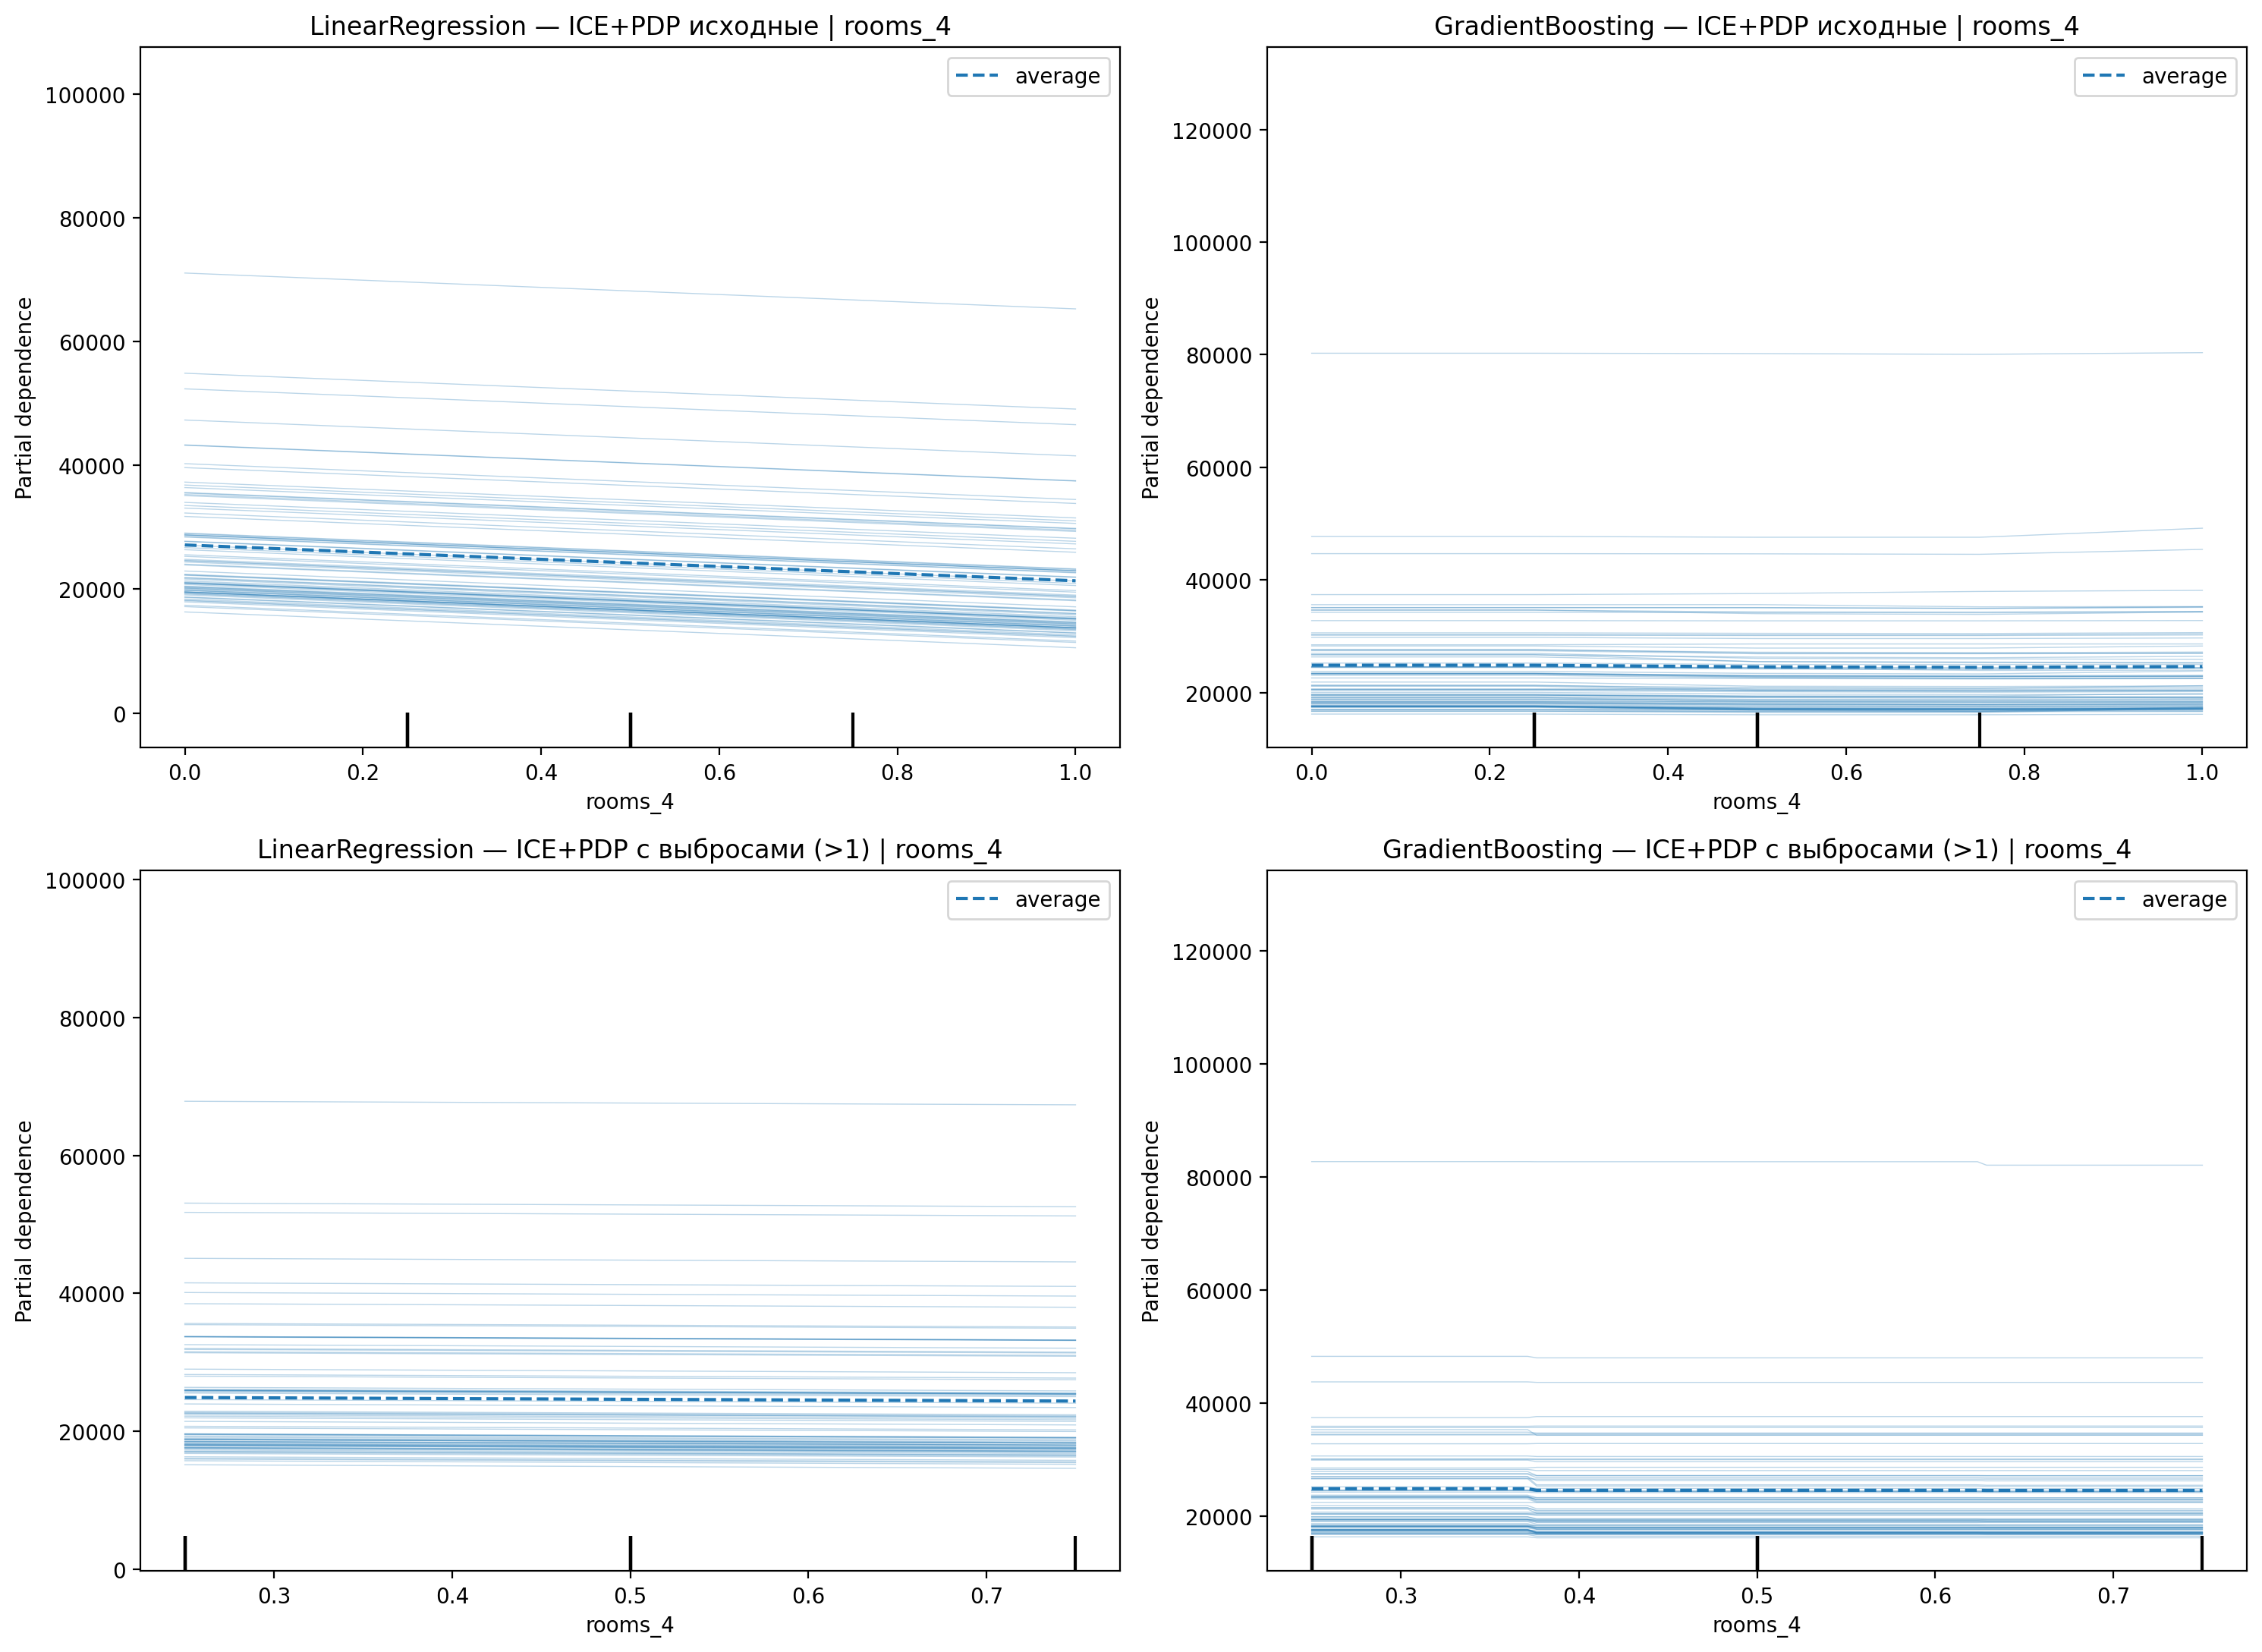

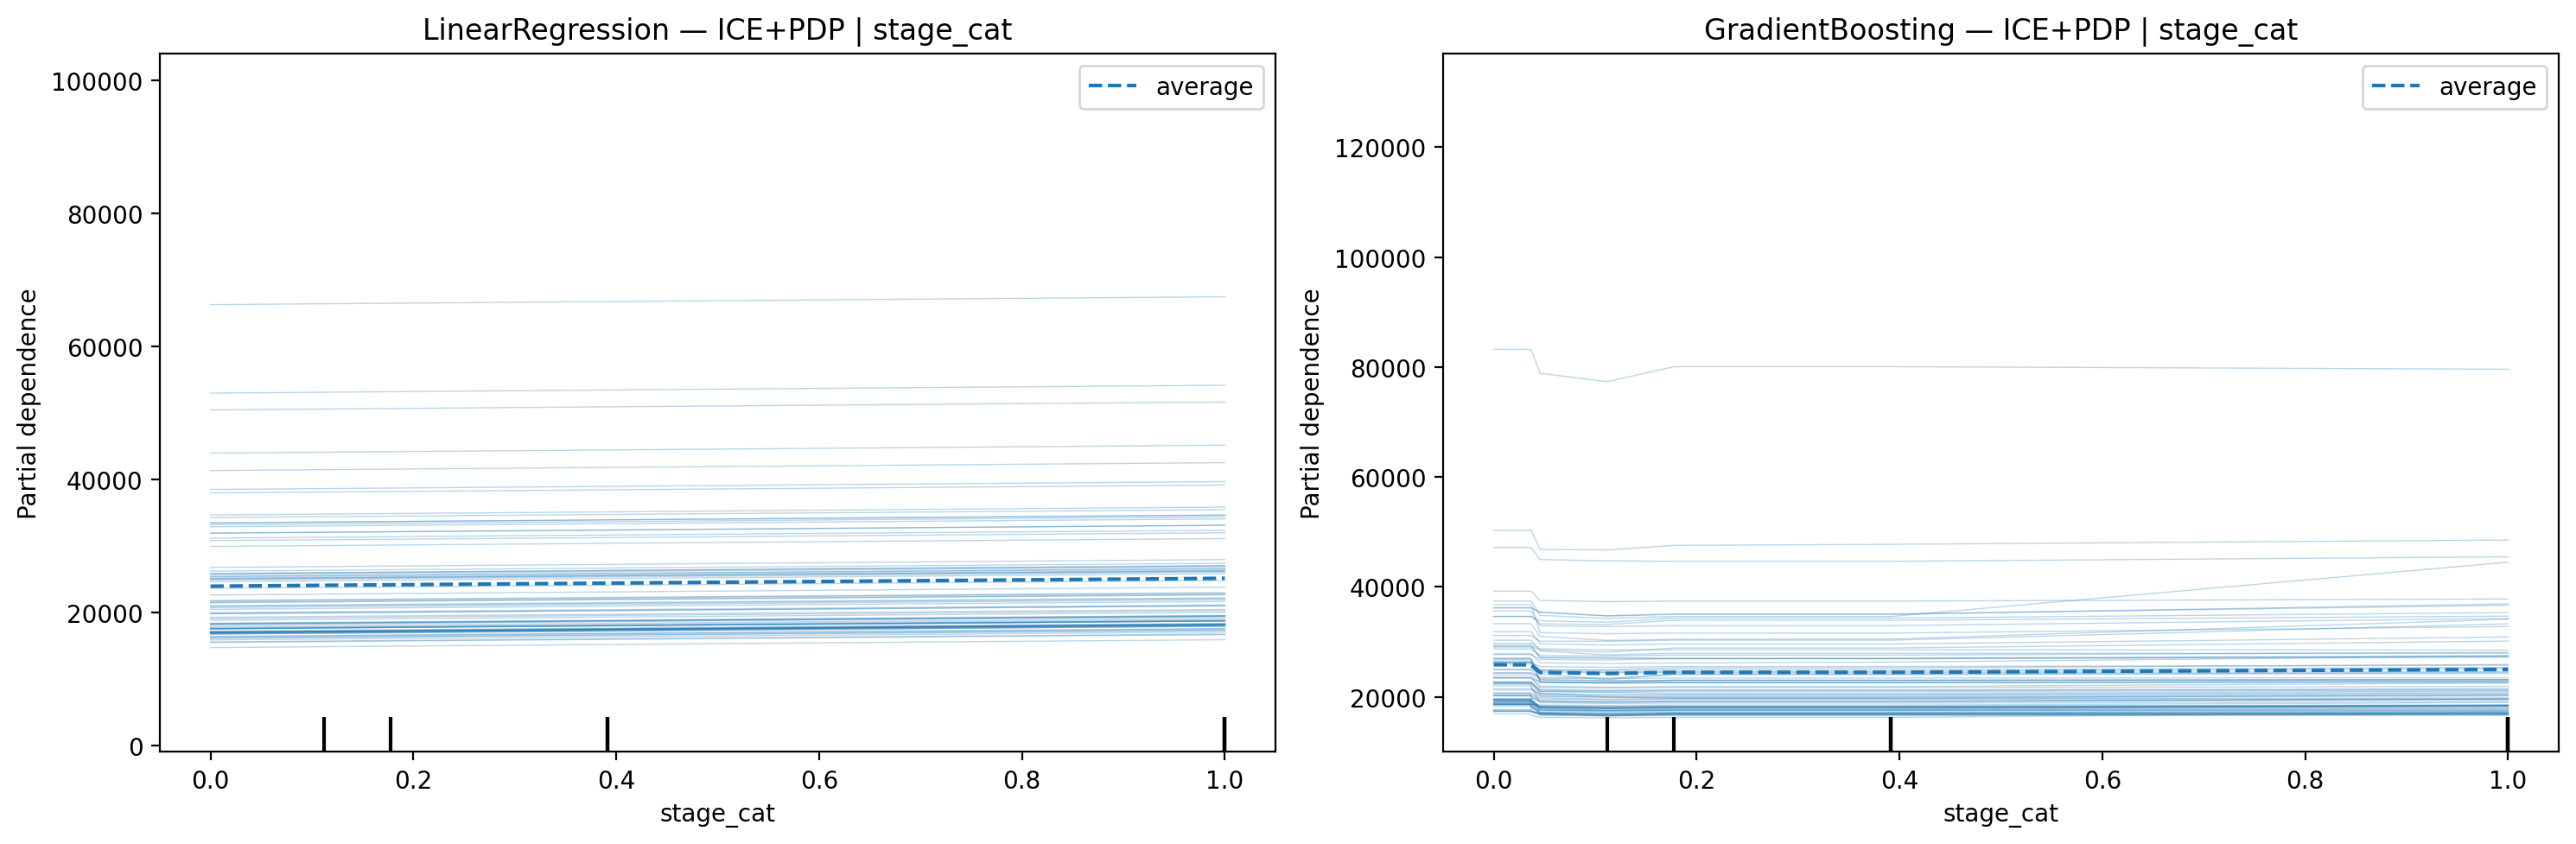

In [17]:
lr_model = LinearRegression().fit(X_train_mm, y_train)
gb_model = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_mm, y_train)

FEATURE = 'rooms_4'
FEATURE2 = 'stage_cat'
feature_idx = feat_names.index(FEATURE)
feature_idx2 = feat_names.index(FEATURE2)


def add_outliers(X_in, idx, n, low=1.5, high=3.0, seed=0):
    rng = np.random.RandomState(seed)
    X_out = X_in.copy()
    rows = rng.choice(len(X_out), n, replace=False)
    X_out[rows, idx] = rng.uniform(low, high, n)
    return X_out


X_train_out = add_outliers(X_train_mm, feature_idx, 300, seed=0)
X_test_out = add_outliers(X_test_mm, feature_idx, 100, seed=1)
lr_out = LinearRegression().fit(X_train_out, y_train)
gb_out = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_out, y_train)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for col, (model, mname) in enumerate([(lr_model, 'LinearRegression'), (gb_model, 'GradientBoosting')]):
    PartialDependenceDisplay.from_estimator(
        model, X_test_mm, [feature_idx], kind='both', subsample=80,
        feature_names=feat_names, ax=axes[0][col], random_state=42)
    axes[0][col].set_title(f'{mname} — ICE+PDP исходные | {FEATURE}')
for col, (model, mname) in enumerate([(lr_out, 'LinearRegression'), (gb_out, 'GradientBoosting')]):
    PartialDependenceDisplay.from_estimator(
        model, X_test_out, [feature_idx], kind='both', subsample=80,
        feature_names=feat_names, ax=axes[1][col], random_state=42)
    axes[1][col].set_title(f'{mname} — ICE+PDP с выбросами (>1) | {FEATURE}')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
for col, (model, mname) in enumerate([(lr_model, 'LinearRegression'), (gb_model, 'GradientBoosting')]):
    PartialDependenceDisplay.from_estimator(
        model, X_test_mm, [feature_idx2], kind='both', subsample=80,
        feature_names=feat_names, ax=axes2[col], random_state=42)
    axes2[col].set_title(f'{mname} — ICE+PDP | {FEATURE2}')
plt.tight_layout()
plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

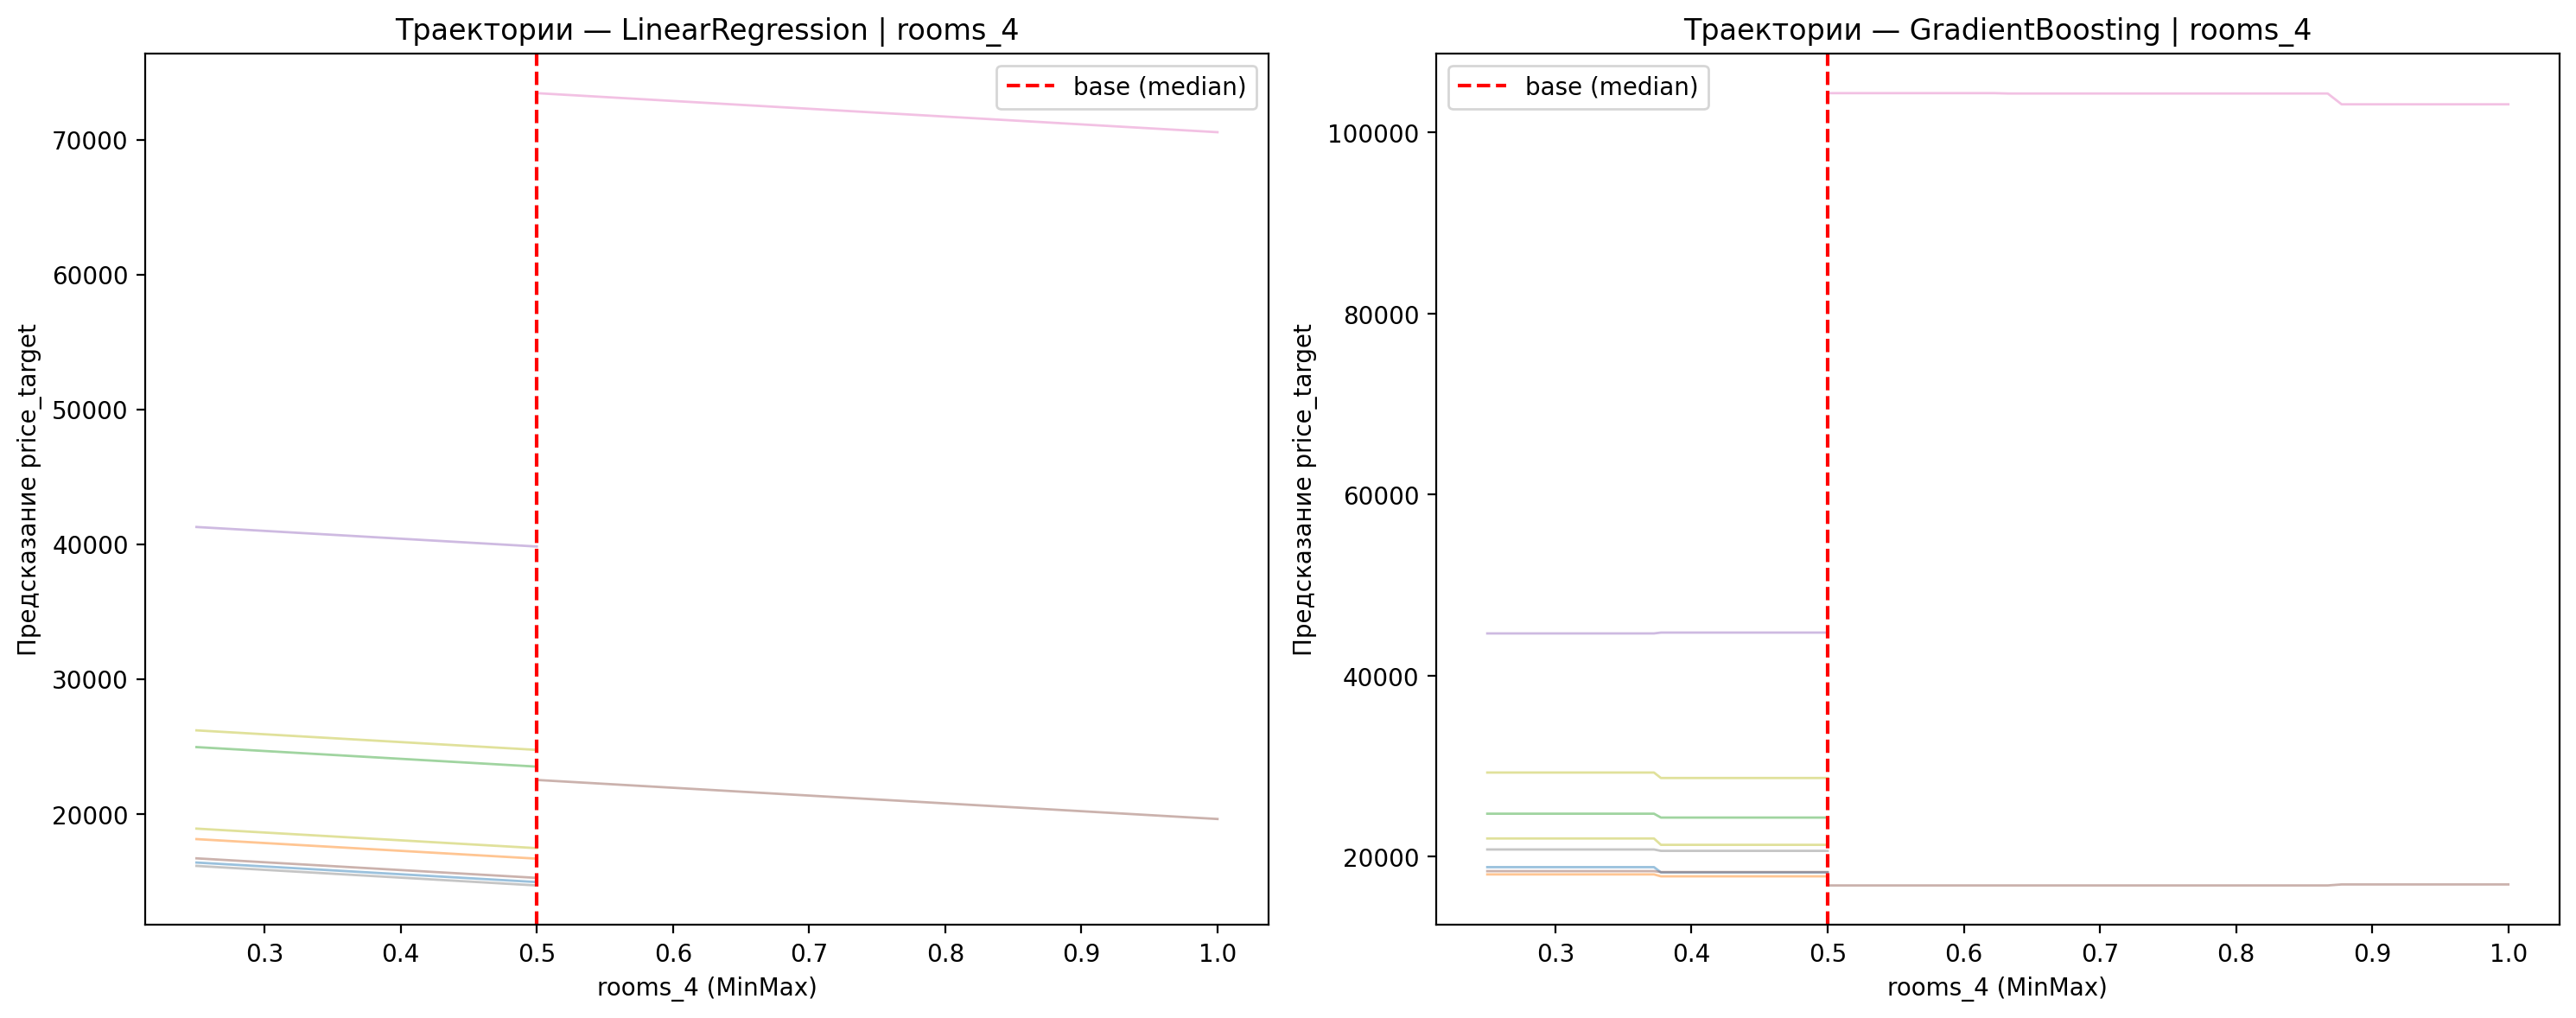

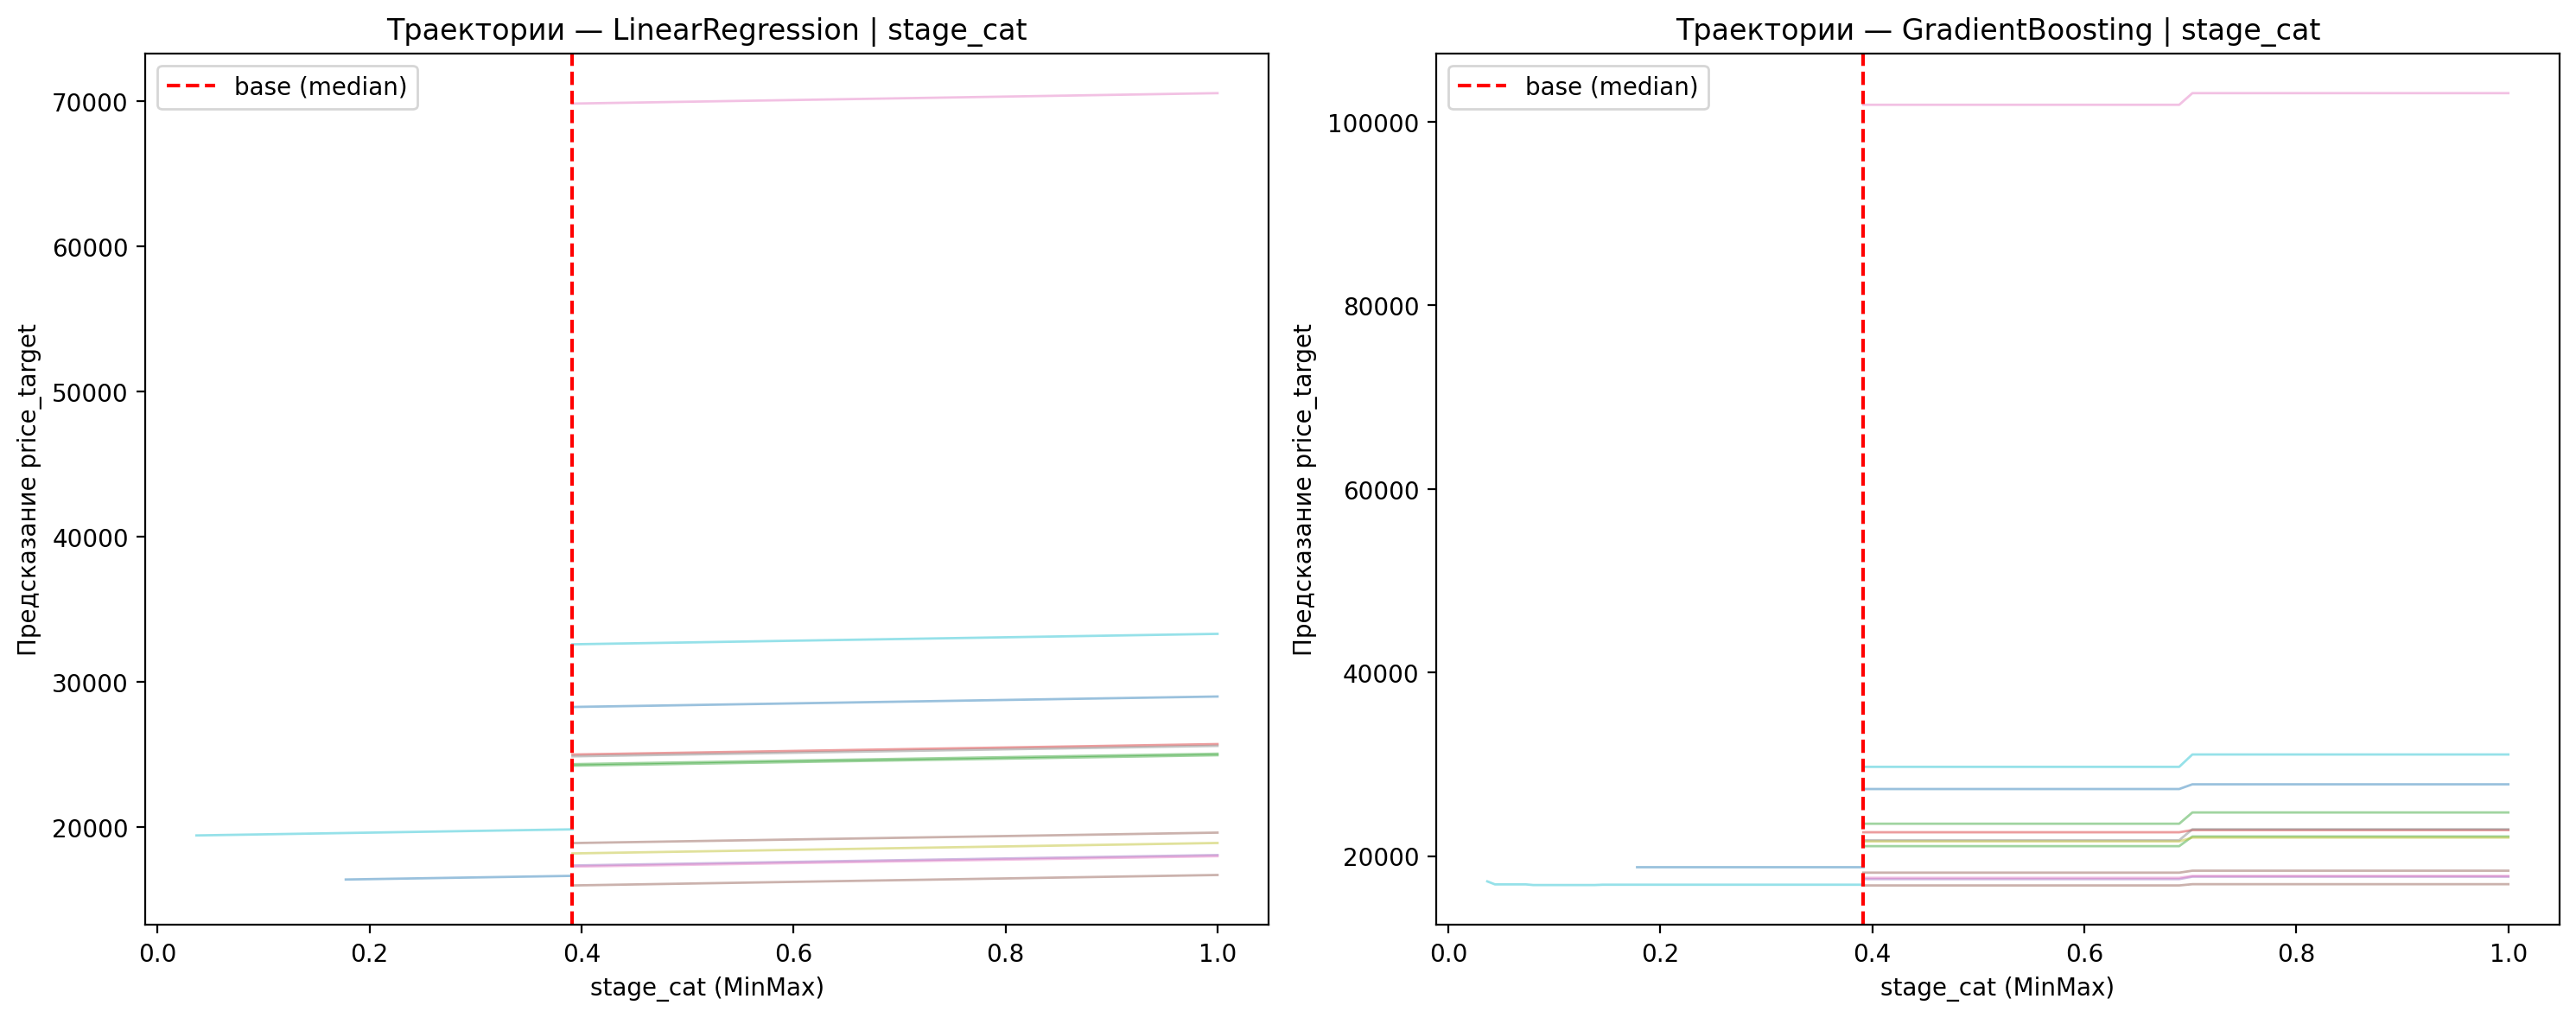

In [18]:
np.random.seed(0)
sample_idx = np.random.choice(len(X_test_mm), 20, replace=False)
X_sample = X_test_mm[sample_idx]
n_steps = 50


def plot_trajectories(feat_idx, fname):
    base_val = np.median(X_train_mm[:, feat_idx])
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, (model, mname) in zip(axes, [(lr_model, 'LinearRegression'), (gb_model, 'GradientBoosting')]):
        for xi in X_sample:
            interp_vals = np.linspace(xi[feat_idx], base_val, n_steps)
            X_path = np.tile(xi, (n_steps, 1))
            X_path[:, feat_idx] = interp_vals
            ax.plot(interp_vals, model.predict(X_path), alpha=0.45, linewidth=1)
        ax.axvline(base_val, color='red', linestyle='--', label='base (median)')
        ax.set_xlabel(f'{fname} (MinMax)')
        ax.set_ylabel('Предсказание price_target')
        ax.set_title(f'Траектории — {mname} | {fname}')
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_trajectories(feature_idx, FEATURE)
plot_trajectories(feature_idx2, FEATURE2)

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


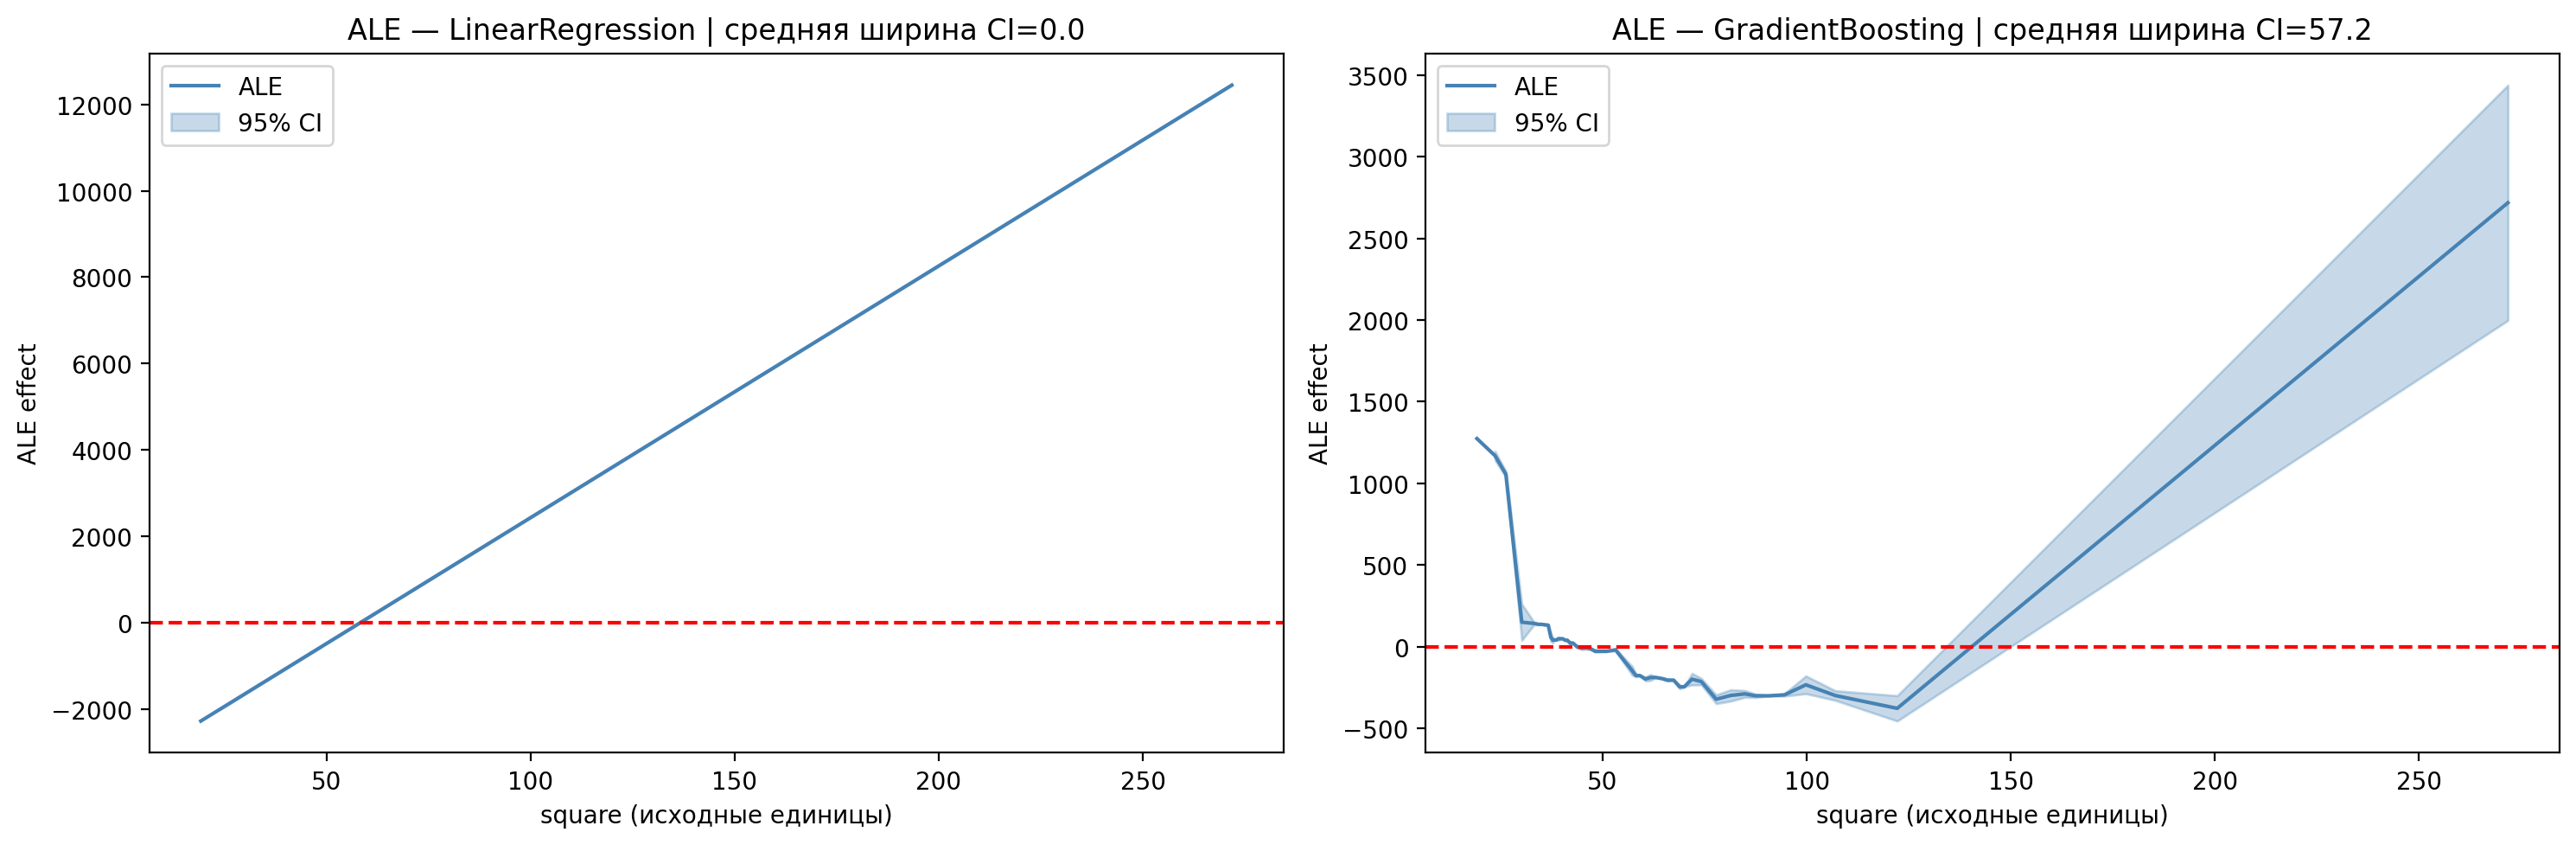

In [19]:
from PyALE import ale

ALE_FEATURE = 'square'

X_train_df = pd.DataFrame(X_train, columns=feat_names)
X_test_df = pd.DataFrame(X_test, columns=feat_names)

lr_raw = LinearRegression().fit(X_train_df, y_train)
gb_raw = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_df, y_train)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (model, mname) in zip(axes, [(lr_raw, 'LinearRegression'), (gb_raw, 'GradientBoosting')]):
    ale_eff = ale(X=X_test_df, model=model, feature=[ALE_FEATURE],
                  grid_size=50, include_CI=True, C=0.95, plot=False)
    ax.plot(ale_eff.index, ale_eff['eff'], color='steelblue', label='ALE')
    ax.fill_between(ale_eff.index, ale_eff['lowerCI_95%'], ale_eff['upperCI_95%'],
                    alpha=0.3, color='steelblue', label='95% CI')
    ci_width = (ale_eff['upperCI_95%'] - ale_eff['lowerCI_95%']).mean()
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel(f'{ALE_FEATURE} (исходные единицы)')
    ax.set_ylabel('ALE effect')
    ax.set_title(f'ALE — {mname} | средняя ширина CI={ci_width:.1f}')
    ax.legend()
plt.tight_layout()
plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?

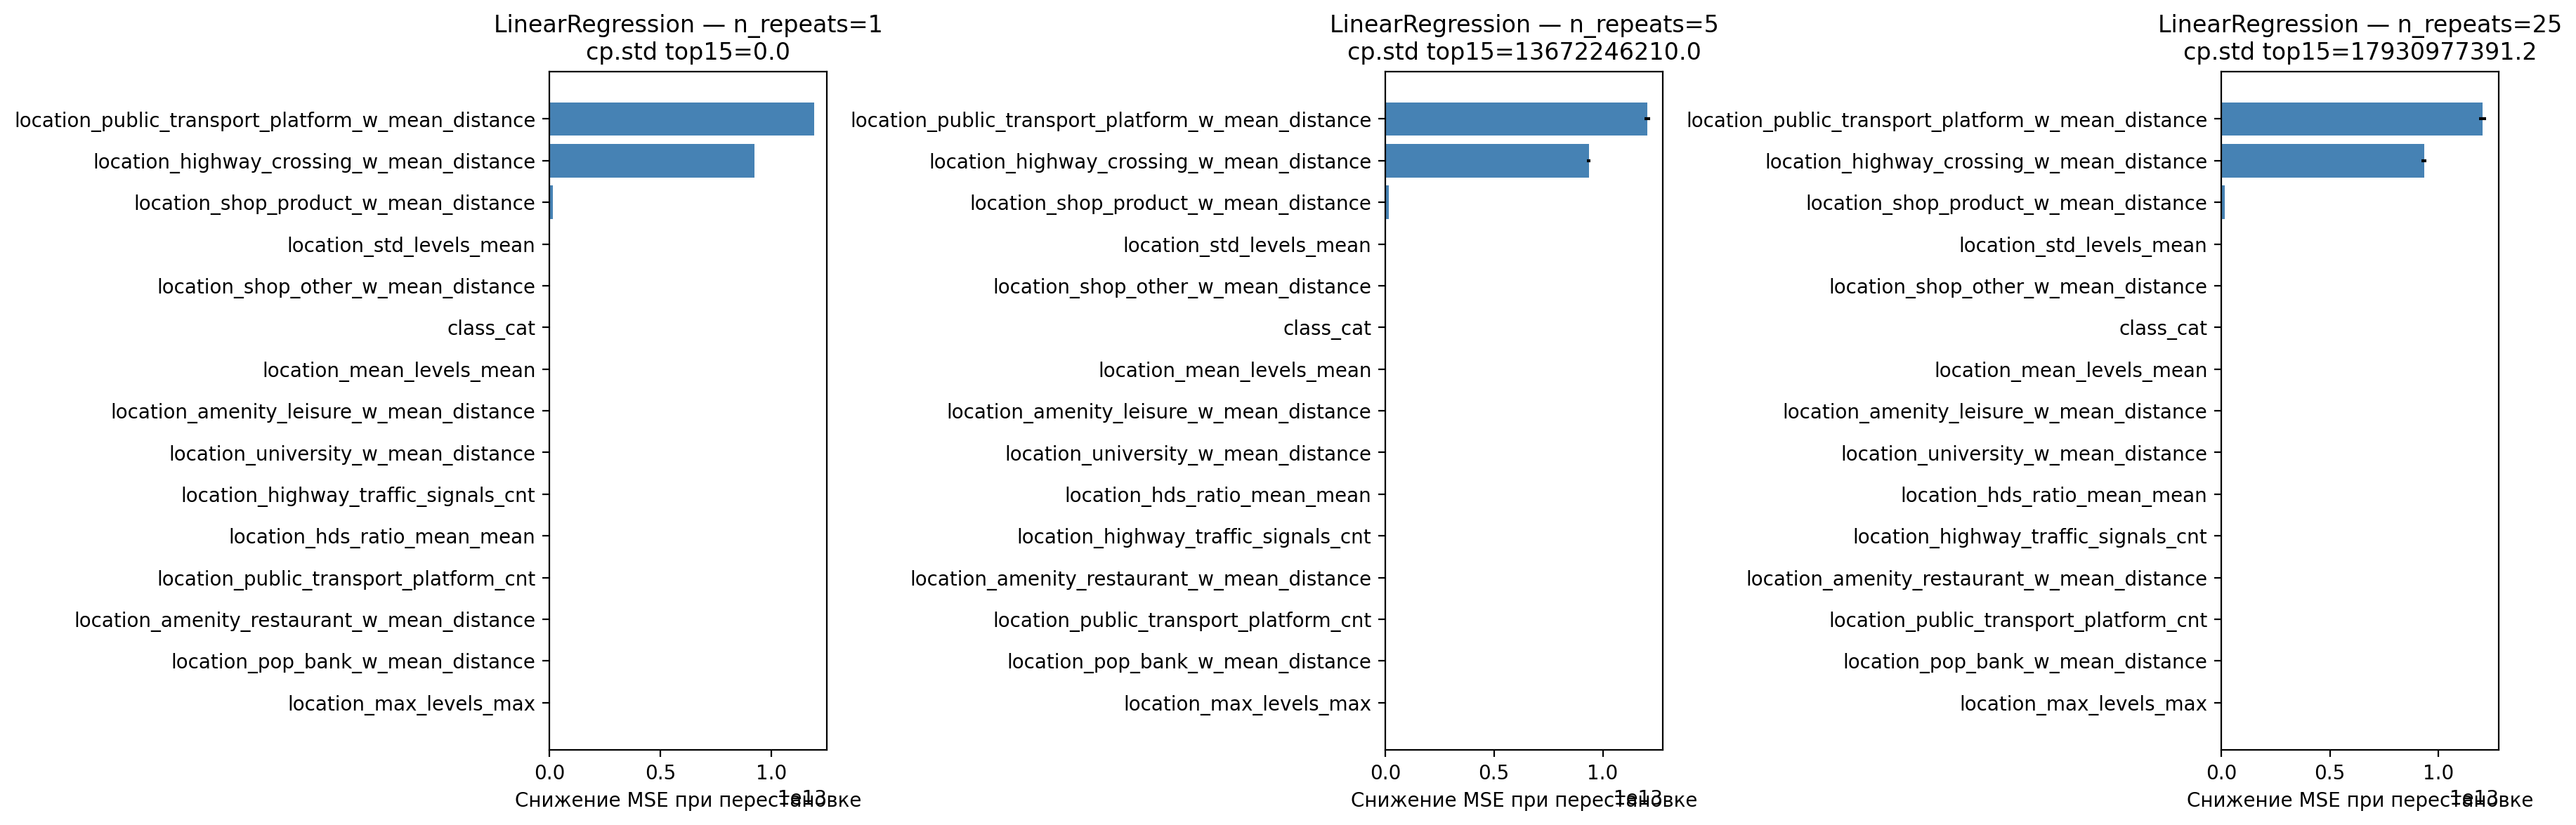

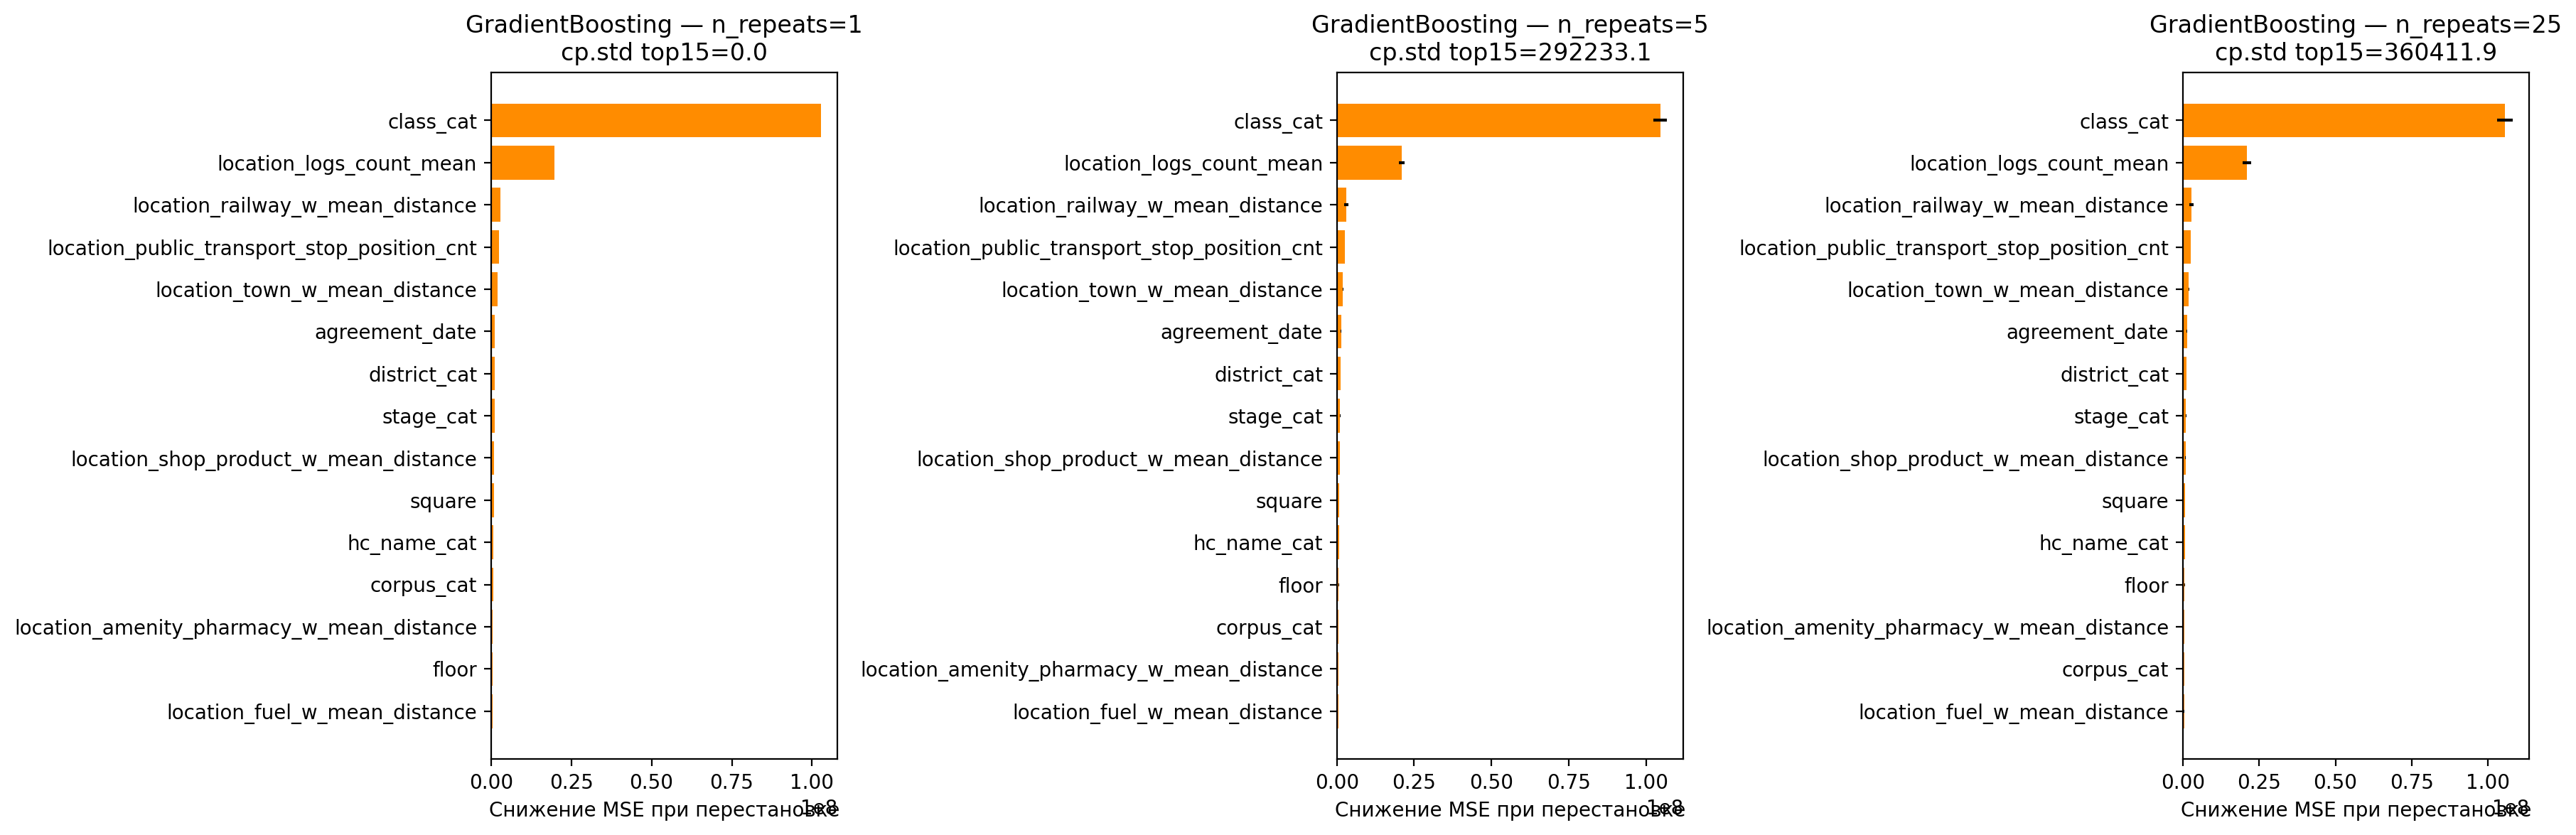

In [20]:
n_repeats_list = [1, 5, 25]

for model, mname, color in [(lr_model, 'LinearRegression', 'steelblue'),
                            (gb_model, 'GradientBoosting', 'darkorange')]:
    fig, axes = plt.subplots(1, len(n_repeats_list), figsize=(18, 6))
    for ax, n_rep in zip(axes, n_repeats_list):
        pi = permutation_importance(model, X_test_mm, y_test, n_repeats=n_rep,
                                    random_state=42, scoring='neg_mean_squared_error')
        idx = np.argsort(pi.importances_mean)[-15:]
        ax.barh(np.array(feat_names)[idx], pi.importances_mean[idx],
                xerr=pi.importances_std[idx], color=color)
        ax.set_title(f'{mname} — n_repeats={n_rep}\nср.std top15={pi.importances_std[idx].mean():.1f}')
        ax.set_xlabel('Снижение MSE при перестановке')
    plt.tight_layout()
    plt.show()

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак.


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

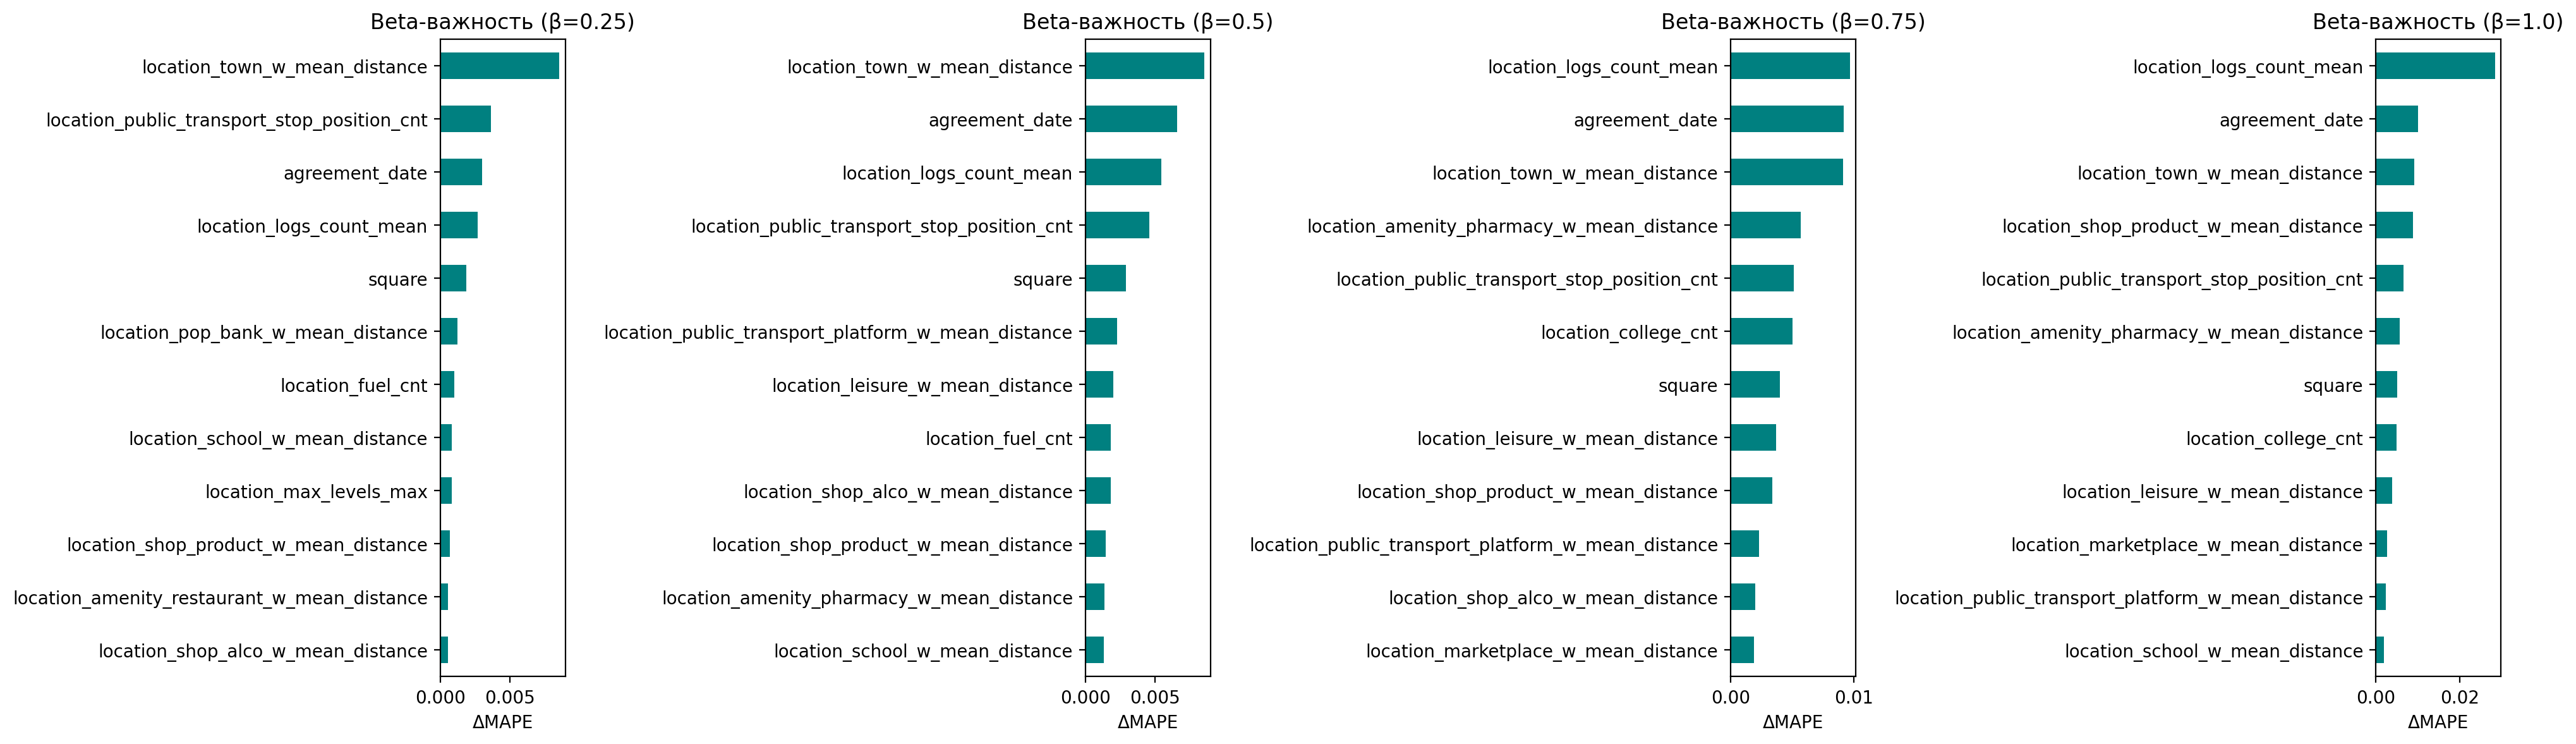

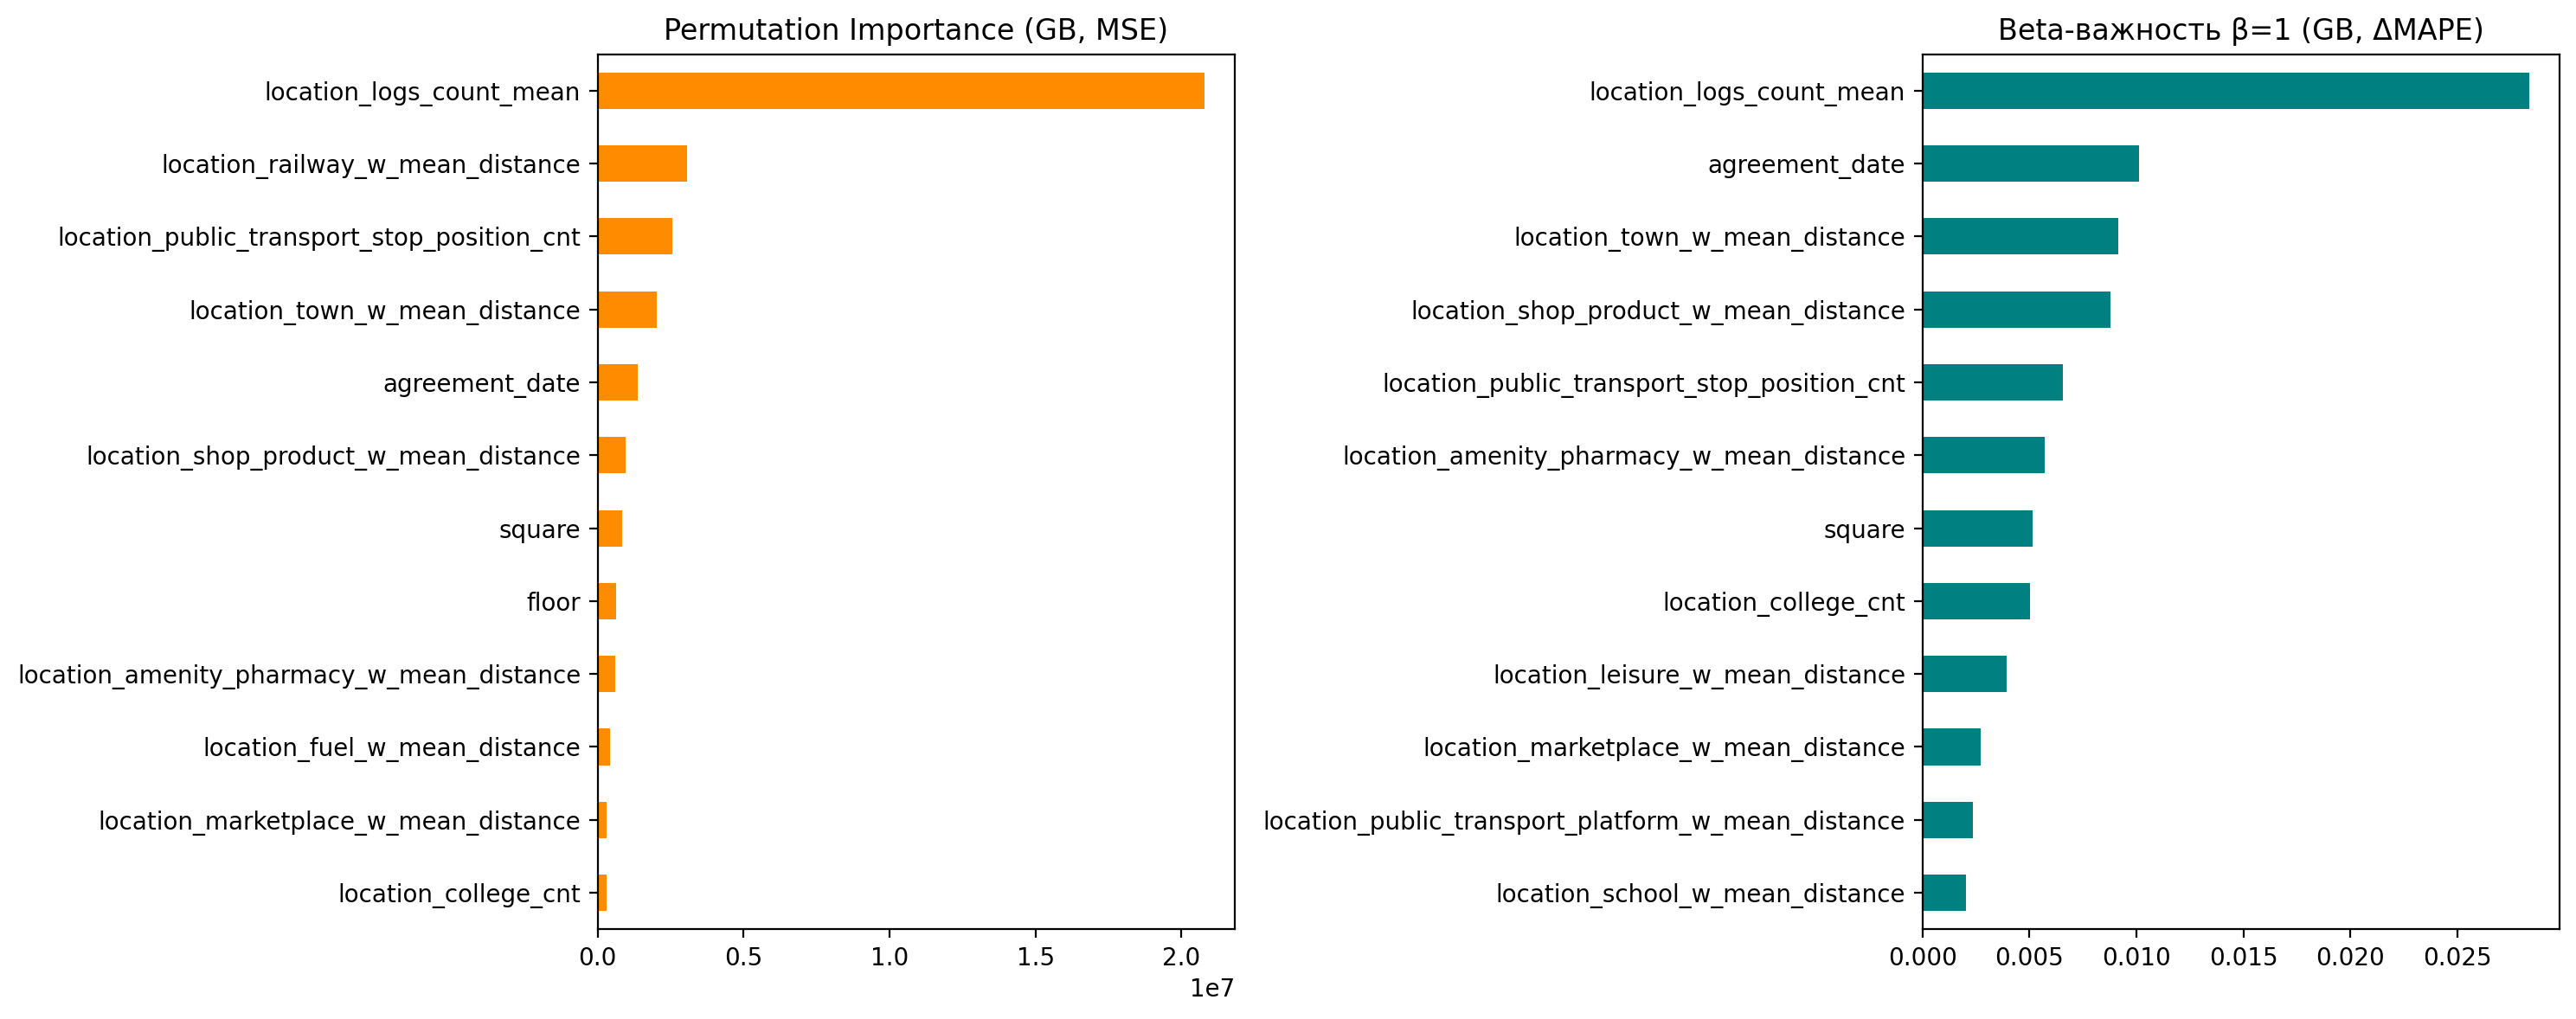

Базовый MAPE бустинга: 0.0380
Топ-5 permutation: ['location_logs_count_mean', 'location_railway_w_mean_distance', 'location_public_transport_stop_position_cnt', 'location_town_w_mean_distance', 'agreement_date']
Топ-5 beta(β=1):   ['location_logs_count_mean', 'agreement_date', 'location_town_w_mean_distance', 'location_shop_product_w_mean_distance', 'location_public_transport_stop_position_cnt']


In [21]:
num_feat_idx = [feat_names.index(c) for c in num_cols]
medians_train = np.median(X_train_mm[:, num_feat_idx], axis=0)
base_mape = mean_absolute_percentage_error(y_test, gb_model.predict(X_test_mm))

betas = [0.25, 0.5, 0.75, 1.0]
importances_beta = {}
for beta in betas:
    imp = []
    for k, fi in enumerate(num_feat_idx):
        X_mod = X_test_mm.copy()
        X_mod[:, fi] = (1 - beta) * X_test_mm[:, fi] + beta * medians_train[k]
        imp.append(mean_absolute_percentage_error(y_test, gb_model.predict(X_mod)) - base_mape)
    importances_beta[beta] = pd.Series(imp, index=num_cols)

fig, axes = plt.subplots(1, len(betas), figsize=(20, 6))
for ax, beta in zip(axes, betas):
    importances_beta[beta].nlargest(12).iloc[::-1].plot.barh(ax=ax, color='teal')
    ax.set_title(f'Beta-важность (β={beta})')
    ax.set_xlabel('ΔMAPE')
plt.tight_layout()
plt.show()

pi_gb = permutation_importance(gb_model, X_test_mm, y_test, n_repeats=10,
                               random_state=42, scoring='neg_mean_squared_error')
pi_ser = pd.Series(pi_gb.importances_mean, index=feat_names)[num_cols]

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
pi_ser.nlargest(12).iloc[::-1].plot.barh(ax=axes2[0], color='darkorange')
axes2[0].set_title('Permutation Importance (GB, MSE)')
importances_beta[1.0].nlargest(12).iloc[::-1].plot.barh(ax=axes2[1], color='teal')
axes2[1].set_title('Beta-важность β=1 (GB, ΔMAPE)')
plt.tight_layout()
plt.show()

print(f"Базовый MAPE бустинга: {base_mape:.4f}")
print("Топ-5 permutation:", list(pi_ser.nlargest(5).index))
print("Топ-5 beta(β=1):  ", list(importances_beta[1.0].nlargest(5).index))

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 

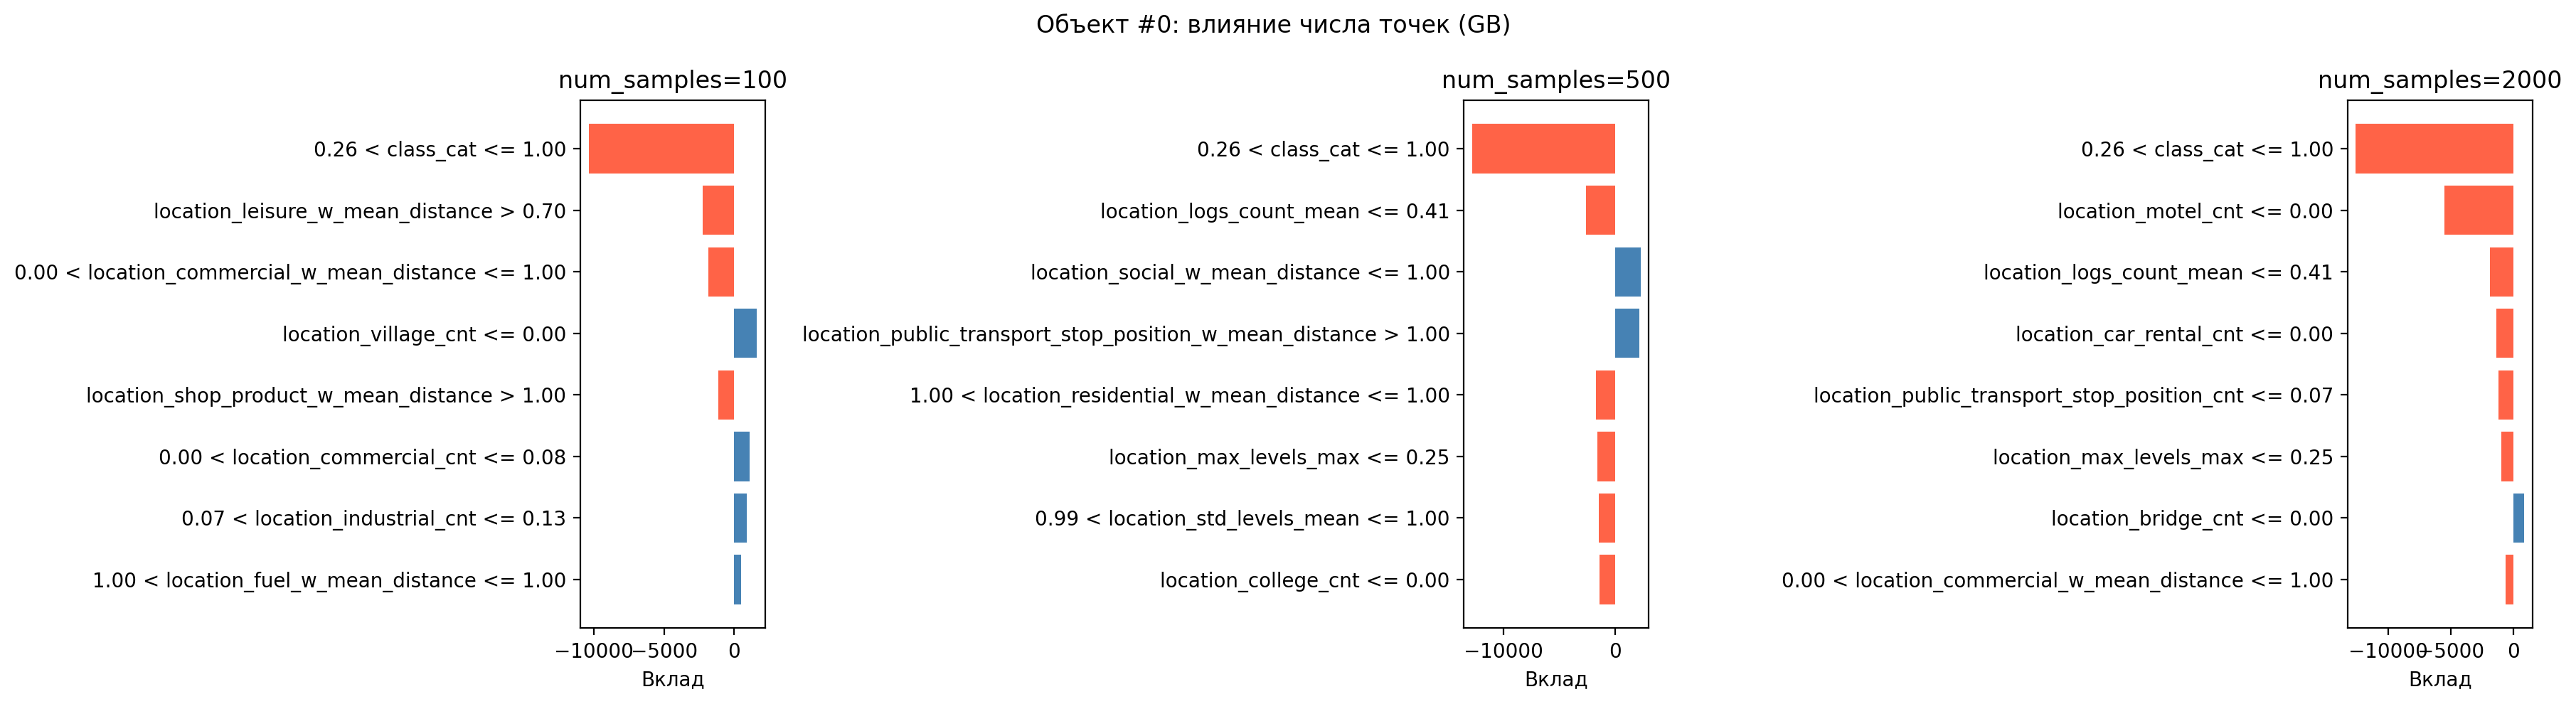

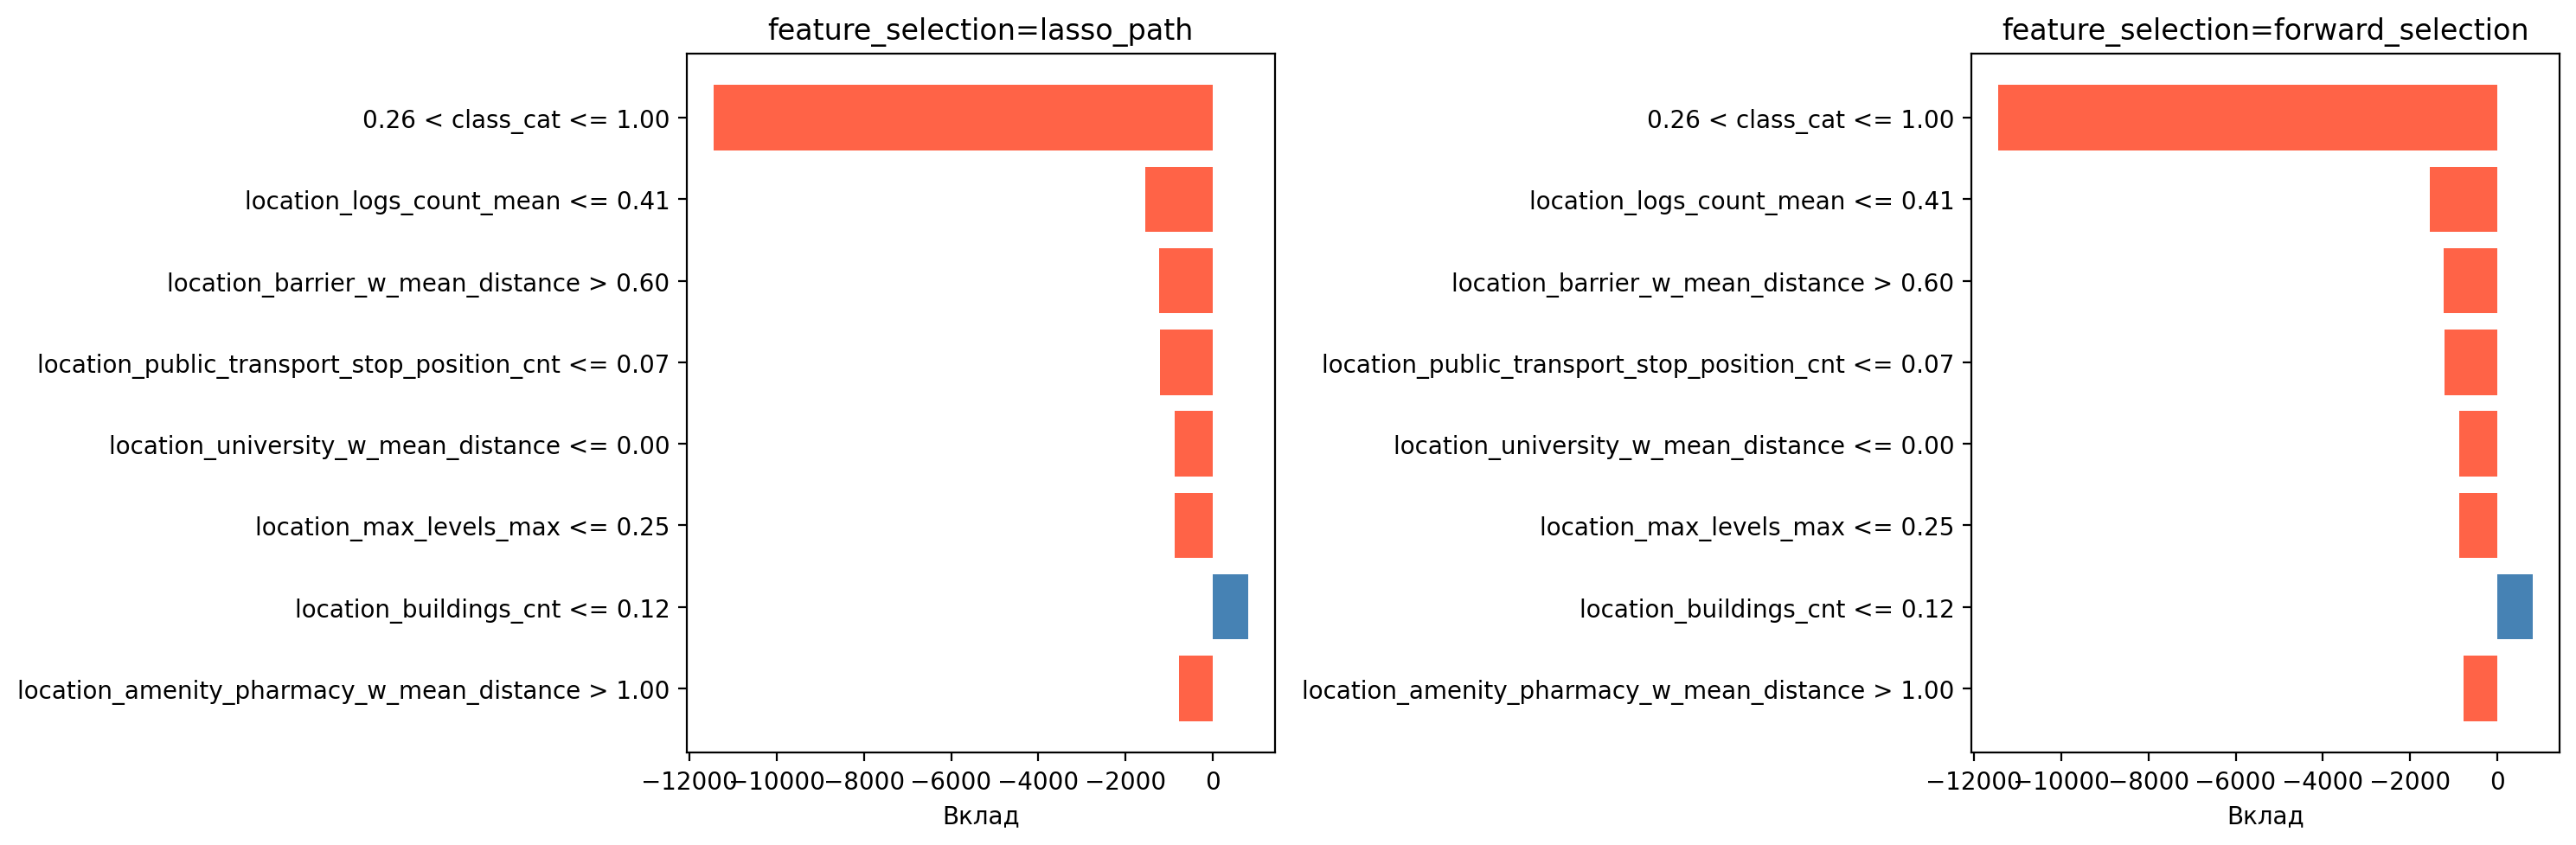

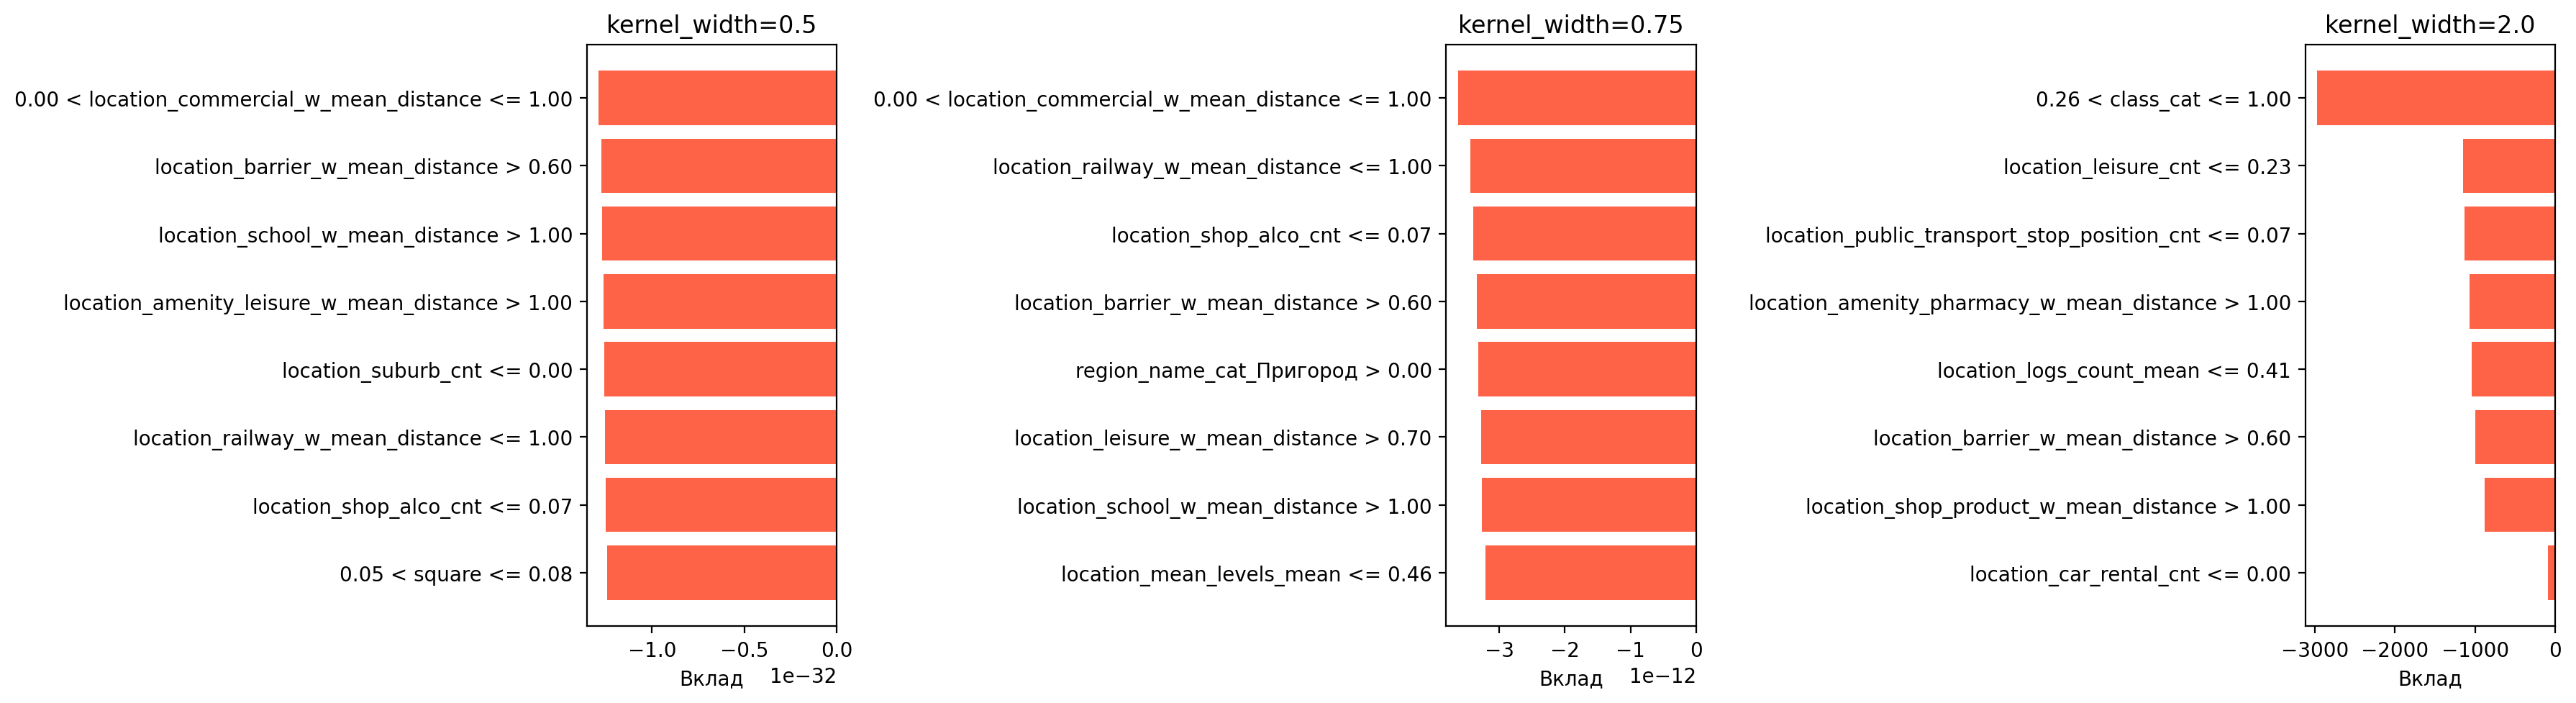

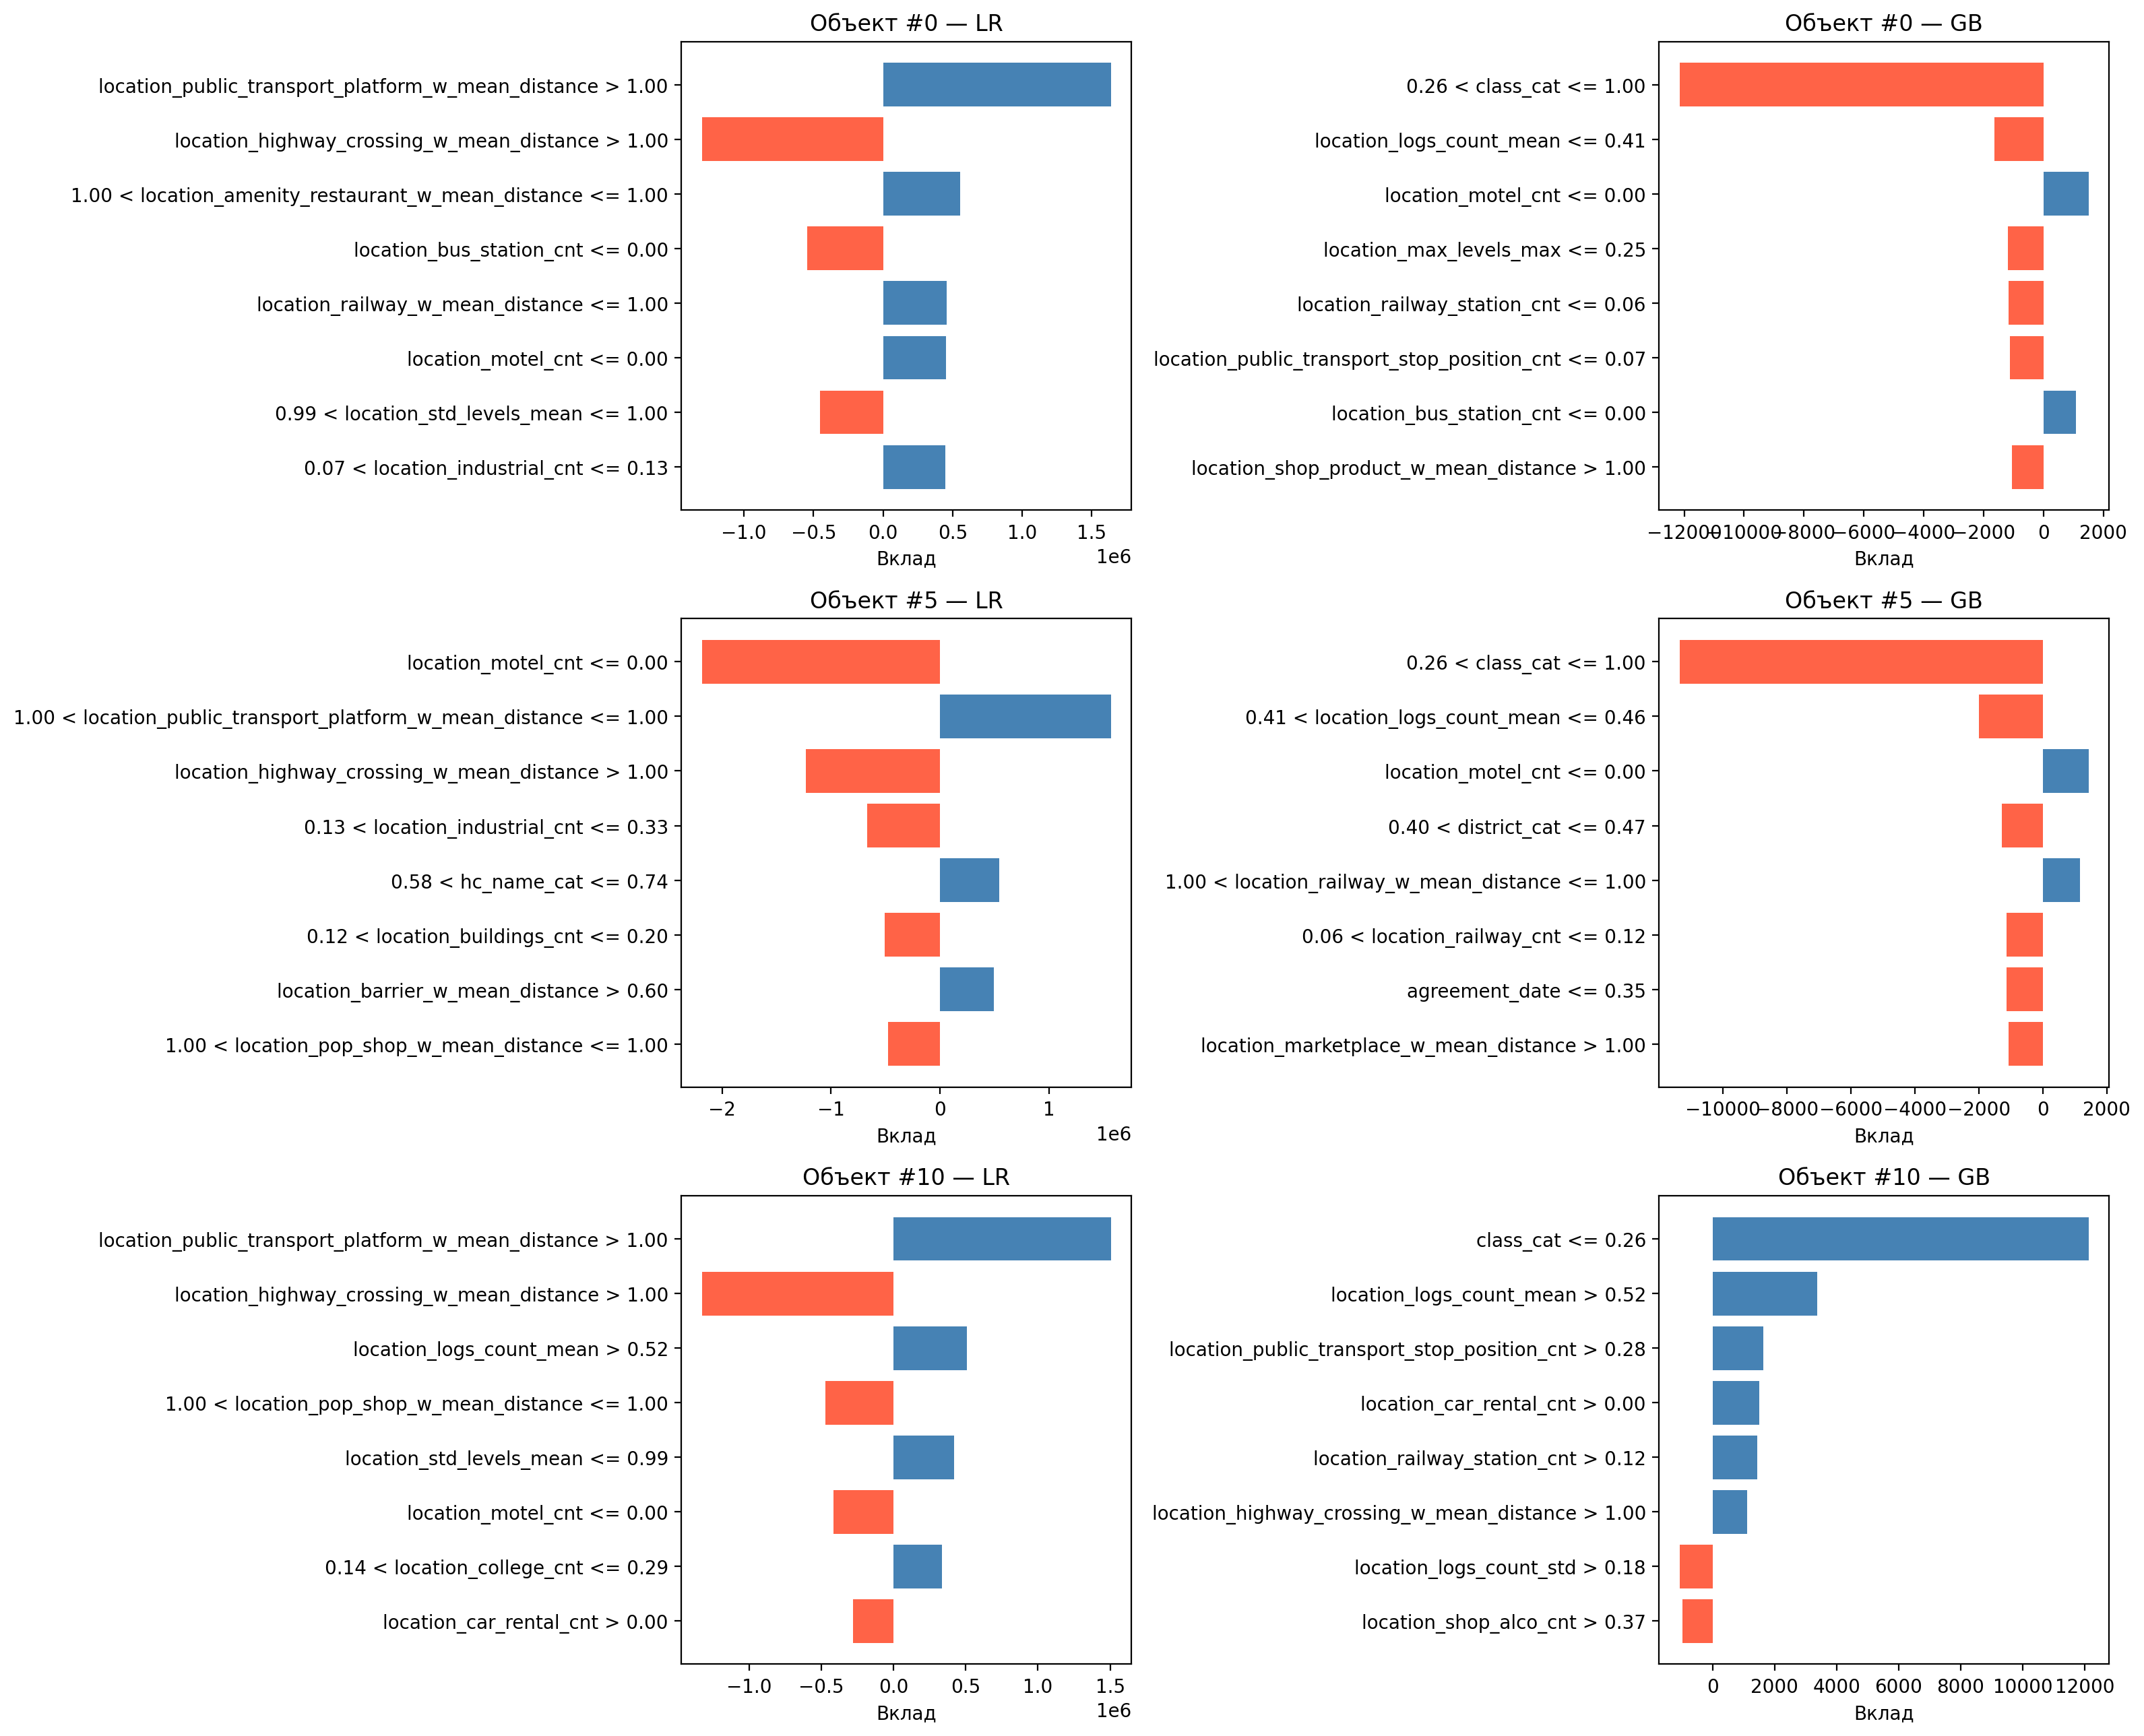

In [22]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_mm, feature_names=feat_names, mode='regression', random_state=42)

idx_demo = 0


def lime_bar(ax, exp, title):
    items = exp.as_list()
    keys = [k for k, _ in items]
    coefs = [v for _, v in items]
    ax.barh(keys[::-1], coefs[::-1],
            color=['steelblue' if c > 0 else 'tomato' for c in coefs[::-1]])
    ax.set_title(title)
    ax.set_xlabel('Вклад')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n_s in zip(axes, [100, 500, 2000]):
    exp = lime_explainer.explain_instance(X_test_mm[idx_demo], gb_model.predict,
                                          num_features=8, num_samples=n_s)
    lime_bar(ax, exp, f'num_samples={n_s}')
plt.suptitle(f'Объект #{idx_demo}: влияние числа точек (GB)')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
for ax, fsel in zip(axes2, ['lasso_path', 'forward_selection']):
    expl_fs = lime.lime_tabular.LimeTabularExplainer(
        X_train_mm, feature_names=feat_names, mode='regression',
        random_state=42, feature_selection=fsel)
    exp = expl_fs.explain_instance(X_test_mm[idx_demo], gb_model.predict,
                                   num_features=8, num_samples=1000)
    lime_bar(ax, exp, f'feature_selection={fsel}')
plt.tight_layout()
plt.show()

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
for ax, kw in zip(axes3, [0.5, 0.75, 2.0]):
    expl_k = lime.lime_tabular.LimeTabularExplainer(
        X_train_mm, feature_names=feat_names, mode='regression',
        random_state=42, kernel_width=kw)
    exp = expl_k.explain_instance(X_test_mm[idx_demo], gb_model.predict,
                                  num_features=8, num_samples=1000)
    lime_bar(ax, exp, f'kernel_width={kw}')
plt.tight_layout()
plt.show()

fig4, axes4 = plt.subplots(3, 2, figsize=(16, 13))
for row, si in enumerate([0, 5, 10]):
    for col, (model, mname) in enumerate([(lr_model, 'LR'), (gb_model, 'GB')]):
        exp = lime_explainer.explain_instance(X_test_mm[si], model.predict,
                                              num_features=8, num_samples=1000)
        lime_bar(axes4[row][col], exp, f'Объект #{si} — {mname}')
plt.tight_layout()
plt.show()

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы.
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 

=== SHAP — LinearRegression ===


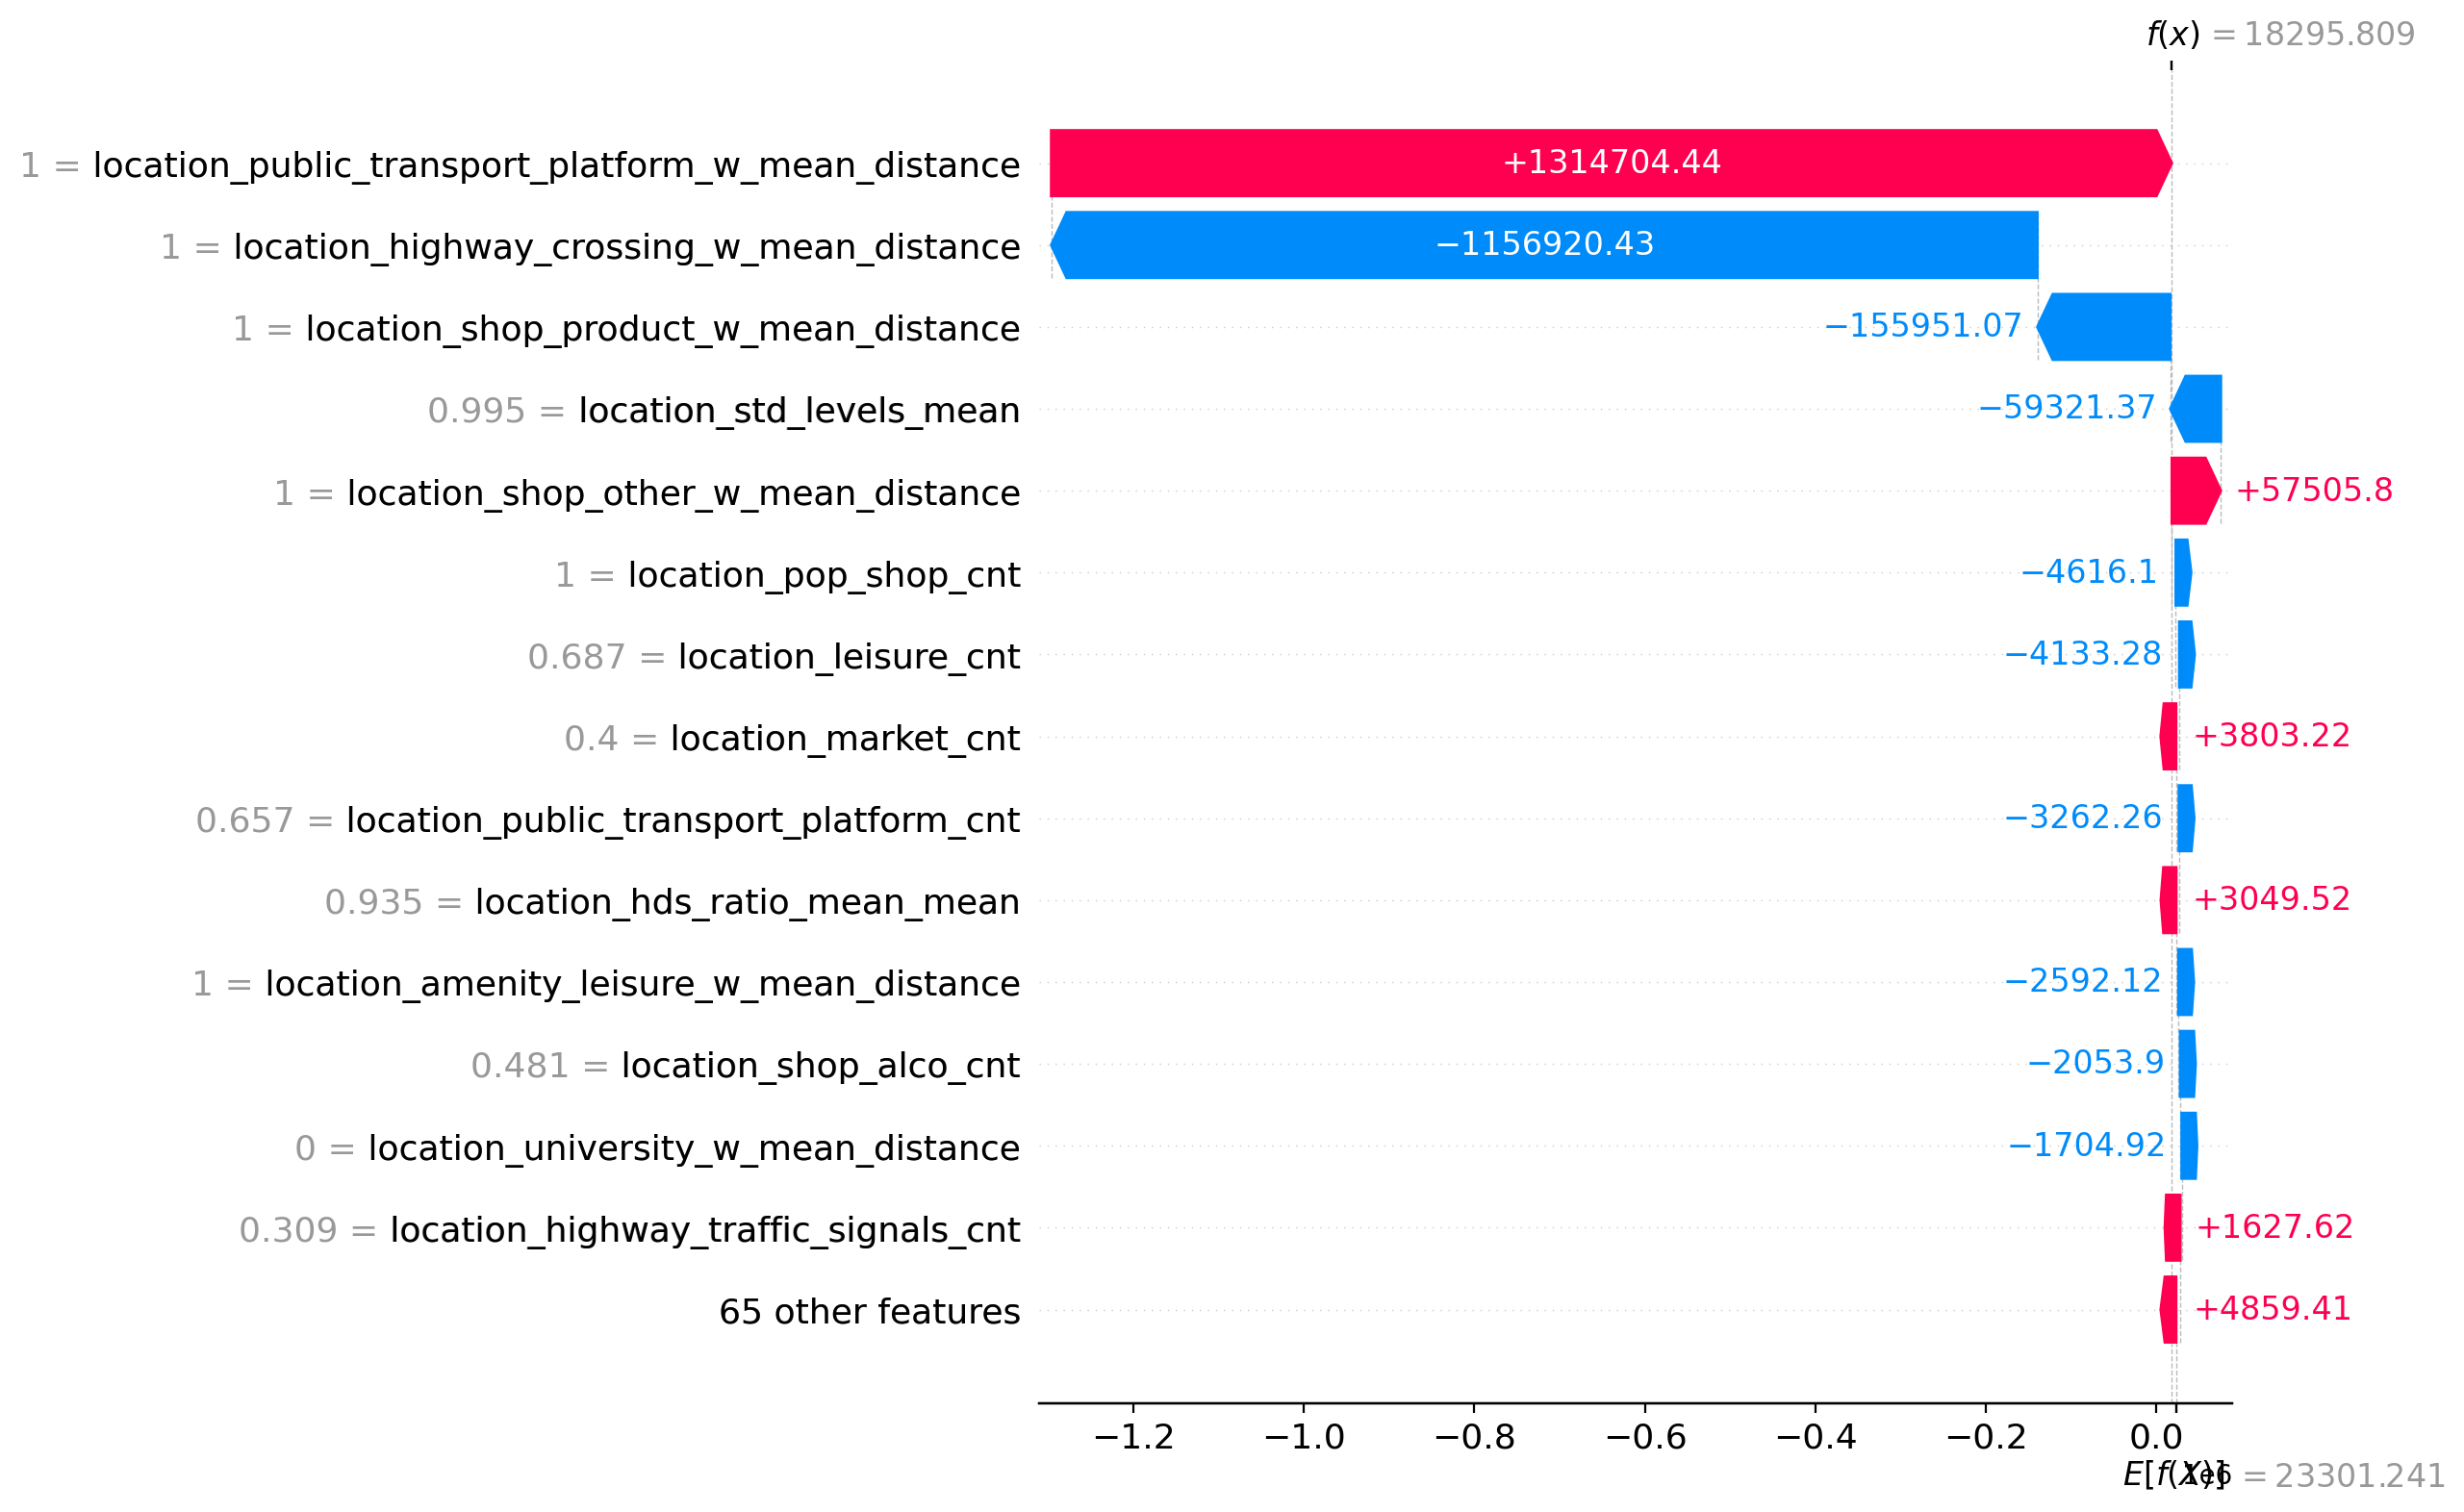

=== SHAP — GradientBoosting ===


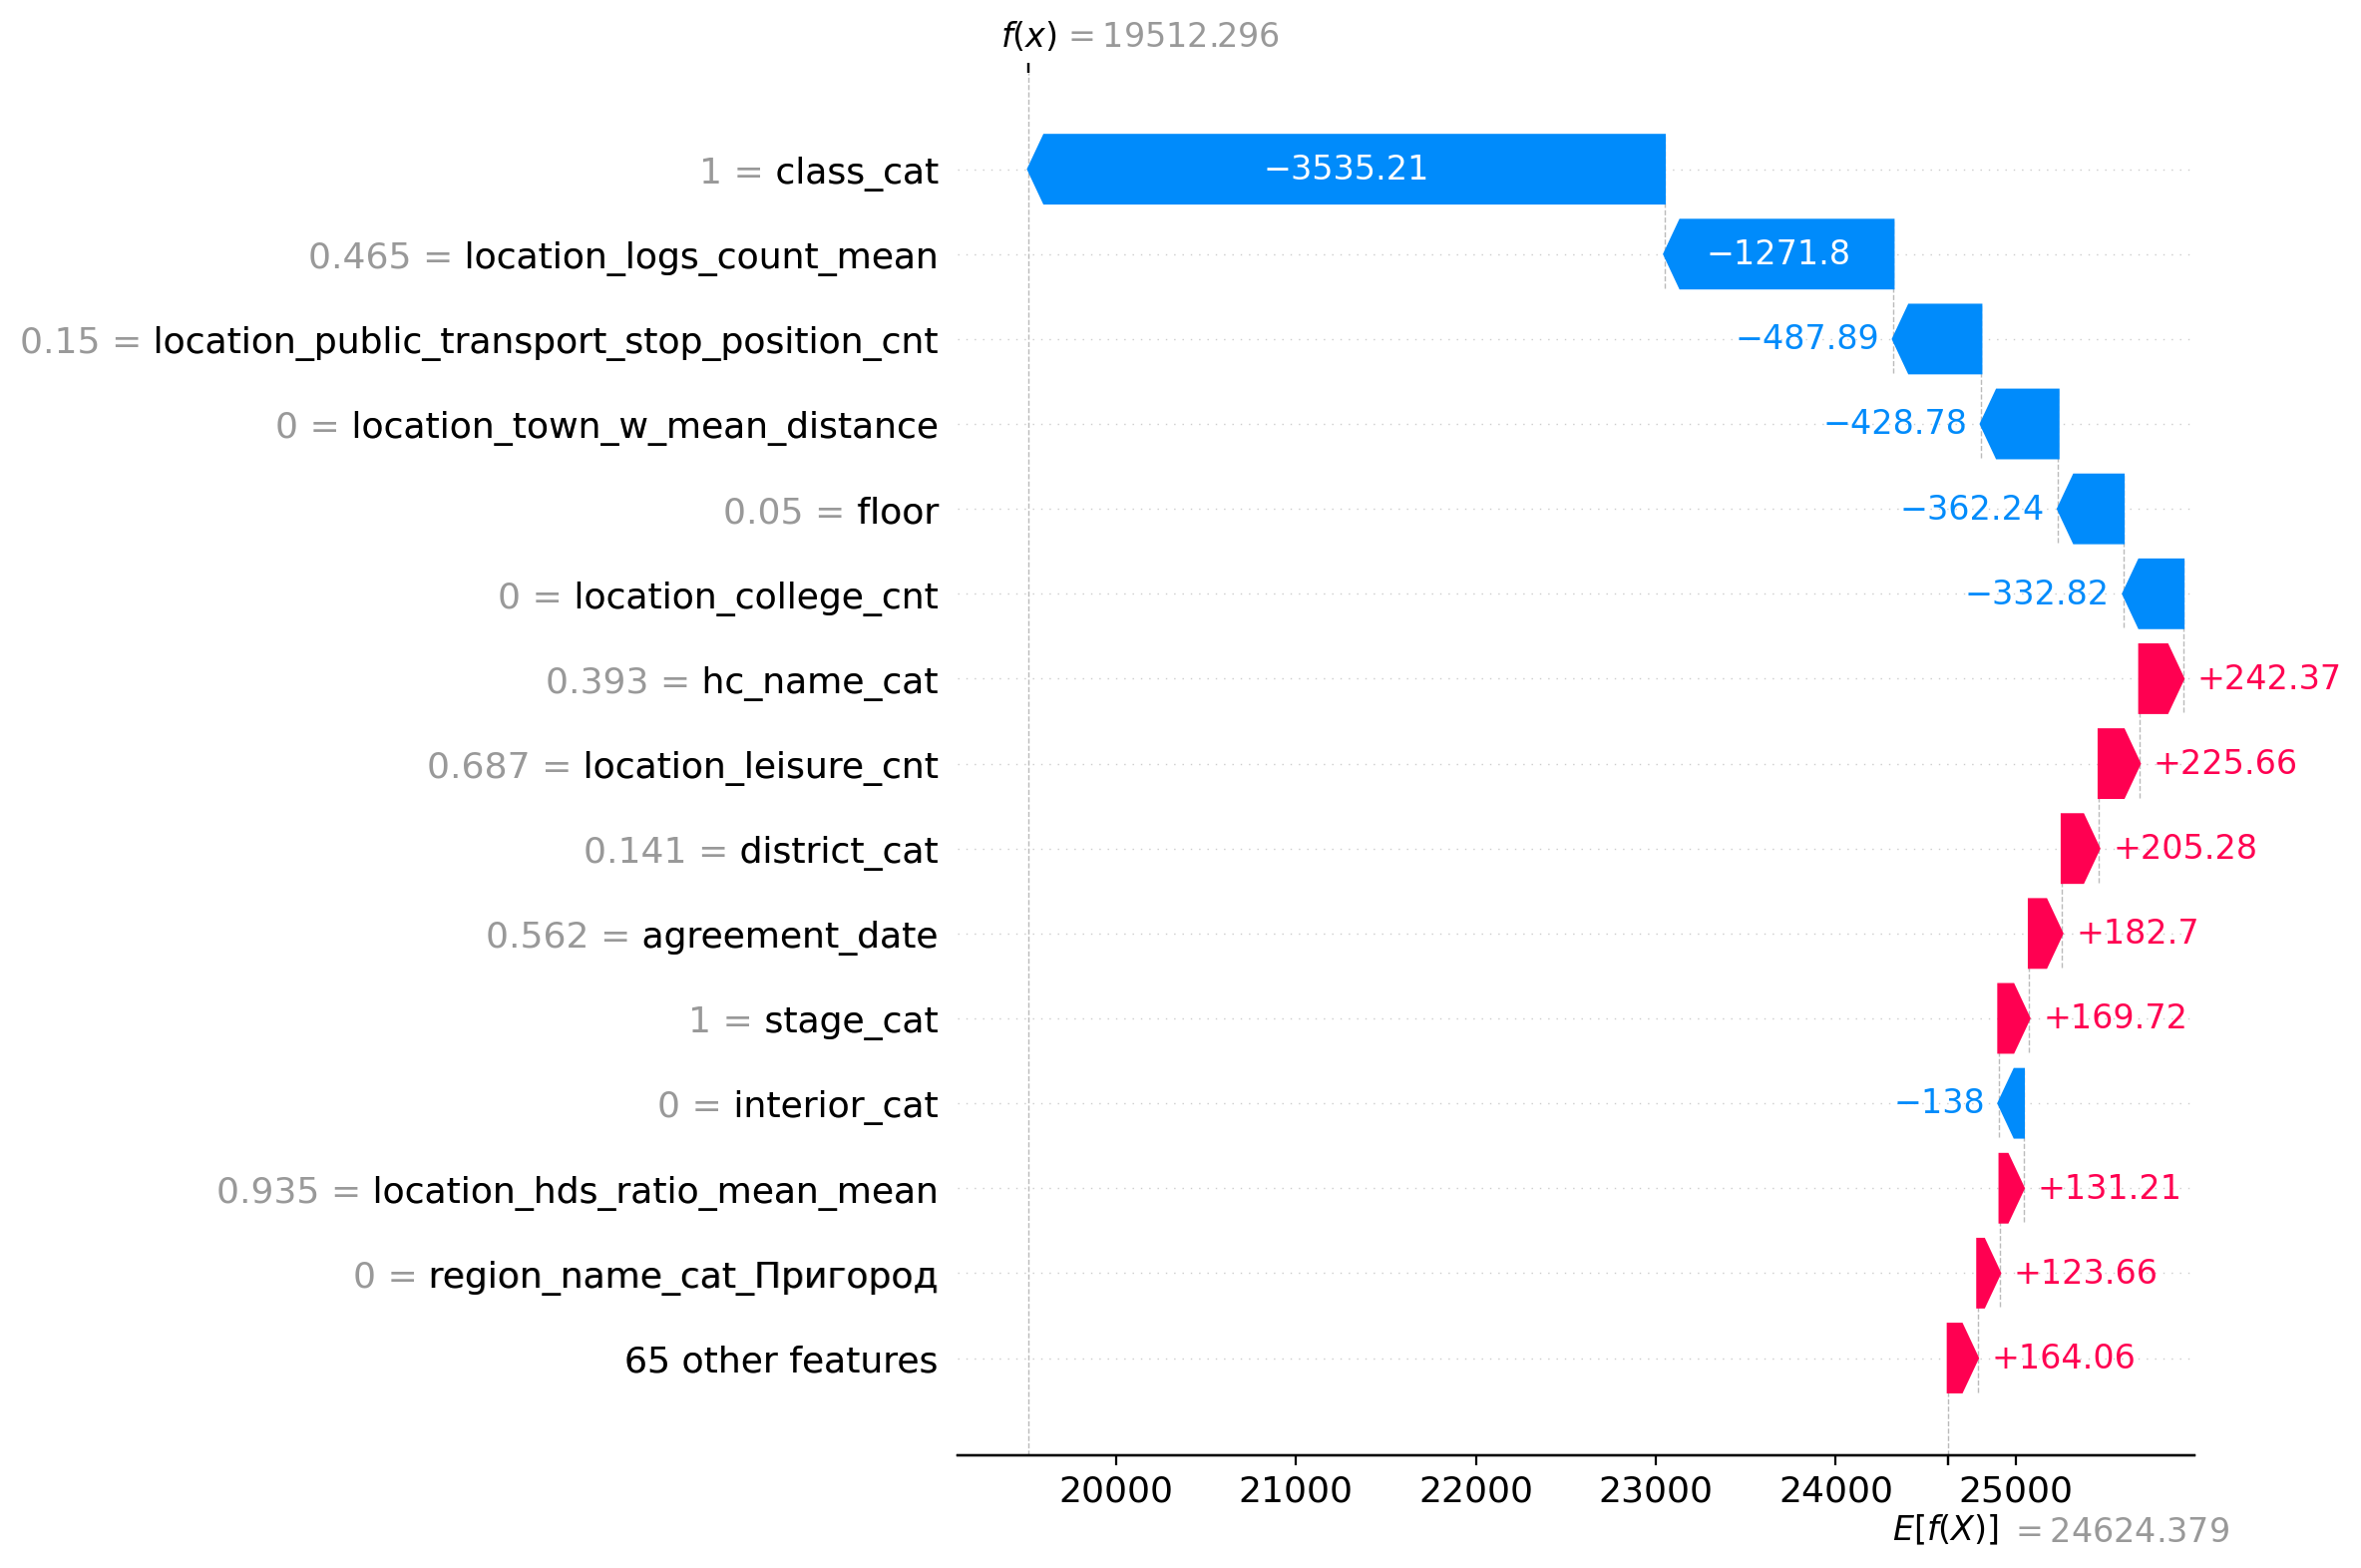

Проверка аддитивности GB: base+sum(phi)=19512.30, предсказание=19512.30


In [24]:
import shap

STUDENT_IDX = 1
x_student = X_test_mm[STUDENT_IDX:STUDENT_IDX + 1]

lr_expl = shap.LinearExplainer(lr_model, X_train_mm)
sv_lr = lr_expl(x_student)
sv_lr.feature_names = feat_names
print("=== SHAP — LinearRegression ===")
shap.plots.waterfall(sv_lr[0], max_display=15, show=True)

gb_expl = shap.TreeExplainer(gb_model)
sv_gb = gb_expl(x_student)
sv_gb.feature_names = feat_names
print("=== SHAP — GradientBoosting ===")
shap.plots.waterfall(sv_gb[0], max_display=15, show=True)

print(f"Проверка аддитивности GB: base+sum(phi)={sv_gb.base_values[0] + sv_gb.values[0].sum():.2f}, "
      f"предсказание={gb_model.predict(x_student)[0]:.2f}")